In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text


# From Raw Employee Reviews to Workplace Insight: Cleaning and Analyzing Glassdoor Job Reviews

## Introduction

Employee reviews provide a unique perspective on workplace quality because they combine numeric evaluations with direct written opinions from workers. These reviews can reveal patterns, related to compensation, work-life balance, management quality and overall employee satisfaction. At the same time, data is often inconsistent and noisy, which makes careful preprocessing essential before any meaningful conclusions can be drawn.\
The aim of this project is to transform a large raw Glassdoor dataset into reliable analytical dataset and to investigate which workplace factors are most strongly associated with positive and negative employee evaluations. In addition to exploratory and comparative analysis, the project also emphasizes practical data-science work such as auditing, missing-value treatment, categorical standardization and text-preprocessing.\
To place the findings in broader context, the analysis is supplemented with a second independent source containing macroeconomic indicators. This allows the project to connect individual workspace reviews with wider economic conditions while preserving the main analytical focus on individual employee review data.

## Problem Formulation

### Problem Statement

Online employee reviews provide a valuable but imperfect source of information about workplace quality. They combined structured evaluation metrics such as ratings for work-life balance, compensation and management with unstructured text fields containing personal experience and opinions. This makes them highly informative, but also difficult to analyze directly because the data may contain missing values, inconsistent categories, noisy text, duplicated entries and other quality issues.\
The central problem of this project is how to transform a large raw employee-review dataset into reliable analytical dataset and use it to extract meaningful insights about workplace satisfaction and dissatisfaction. The project focuses not only on identifying patterns in employee evaluations, but also on demonstrating a full data science workflow: data auditing, cleaning, preprocessing, exploratory analysis and interpretation.\
More specifically, the analysis aims to examine which workplace factors are more strongly associated with positive and negative overall evaluations, whether current and former employees differs in their assessments and what themes are most common in positive and negative textual feedback. A secondary data source is included to provide more broader economic context, but the main analytical focus will remain n the Glassdoor review data.

### Research questions

1. What data quality issues are present in Glassdoor employee review dataset and how they can be treated appropriately?
2. Which structured workplace factors are most strongly associated with overall employee ratings?
3. Do current and former employees evaluate their workplaces differently?
4. What are most common themes in positive and negative textual reviews?
5. How can broader economic conditions help contextualise employee perceptions of compensation, benefits and workplace quality?

### Hypotheses

**H1.** Higher ratings for work-life balance, compensation and benefits, career opportunities and senior management are associated with higher overall employee ratings.\
**H2.** Former employees tend to leave less favorable reviews than current employees.\
**H3.** Negative textual reviews more frequently emphasize themes related to poor management, heavy workload, limited career growth and dissatisfaction with compensation.\
**H4.** Positive textual reviews more often emphasize flexibility, supportive colleagues, benefits and workplace culture.\
**H5.** Broader economic pressure may be reflected in strong dissatisfaction with compensation-related aspects of work, although this relationship should be interpreted as contextual rather than causal.

## Data Sources

This project uses two independent data sources.

The main source is the **Glassdoor Job Reviews** dataset obtained from Kaggle. It contains large number of employee reviews and combines structured evaluation variables with unstructured textual feedback. The structured variables inlcude measures such as overall rating, work-life balance, compensation and benefits, career opportunities, senior management evaluation, recommendation indicators and employment status. In addition, the dataset includes text-free fields such as review headlines, pros and cons. This makes it suitable both for workplace analysis and for demonstrating data-cleaning and preprocessing techniques.\
The second source is macroeconomic dataset obtained from the **World Bank World Development Indicators** database. It includes selected indicators such as inflation, GDP growth and unemployment rates for set of countries in time period 2010-2025. Unlike the Glassdoor dataset, this set is not used for individual-level analysis. Instead, it serves a supporting role by providing broader economic context for the interpretation of employee review patterns.  

### Methodology

The analytical workflow of this project follows the OSEMN framework: obtaining the data, scrubbing and preprocessing it, exploring its structure and patterns, applying analytical methods and intepreting the results. In practice, the methodology is adapted to the specific characteristics of the datasets used in the project.\
The analysis begins with loading the datasets and performing initial inspection in order to understand their structure, variable types and potential data quality issues. This is followed by data-cleaning and preprocessing stage, where missing values, duplicated observations, inconsistent categorical labels and noisy text fields are identified and treated appropriately.\
After the data has been prepared, the project proceeds with exploratory data analysis in order to examine the distribution of key variables and the relationship between key workplace factors and overall employee evaluations. Particular attention is given to current and former employees, as well as to the relationship between structured ratings and text-free feedback.\
The textual fields are then processed separately in order to identify common themes in positive and negative review. Finally, the World Bank dataset is used to provide broader economic context for the interpretation of the review-based findings. The results are discussed with attention to the limitations of the data and the scope of the conclusions that can be reasonably drawn.

### Data Loading and Initial Inspection

The first practical step of the analysis is to load the datasets and inspect their structure, dimensions, variables types and initial data quality characteristics.

In [2]:
glassdoor_reviews = pd.read_csv("glassdoor_reviews.csv")

In [3]:
glassdoor_reviews.shape

(838566, 18)

In [4]:
glassdoor_reviews.head(5)

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [5]:
glassdoor_reviews.dtypes

firm                    object
date_review             object
job_title               object
current                 object
location                object
overall_rating           int64
work_life_balance      float64
culture_values         float64
diversity_inclusion    float64
career_opp             float64
comp_benefits          float64
senior_mgmt            float64
recommend               object
ceo_approv              object
outlook                 object
headline                object
pros                    object
cons                    object
dtype: object

The initial inspection shows that the dataset contains both structured and unstructured variables. At this stage, main goal is to identify potential data quality issues such as missing values, duplicated observations, inconsistent formats and variables that may require type conversion.

In [6]:
glassdoor_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 838566 non-null  object 
 1   date_review          838566 non-null  object 
 2   job_title            838566 non-null  object 
 3   current              838566 non-null  object 
 4   location             541223 non-null  object 
 5   overall_rating       838566 non-null  int64  
 6   work_life_balance    688672 non-null  float64
 7   culture_values       647193 non-null  float64
 8   diversity_inclusion  136066 non-null  float64
 9   career_opp           691065 non-null  float64
 10  comp_benefits        688484 non-null  float64
 11  senior_mgmt          682690 non-null  float64
 12  recommend            838566 non-null  object 
 13  ceo_approv           838566 non-null  object 
 14  outlook              838566 non-null  object 
 15  headline         

In [7]:
glassdoor_reviews.isna().sum().sort_values(ascending=False)

diversity_inclusion    702500
location               297343
culture_values         191373
senior_mgmt            155876
comp_benefits          150082
work_life_balance      149894
career_opp             147501
headline                 2590
cons                       13
pros                        2
date_review                 0
overall_rating              0
current                     0
recommend                   0
ceo_approv                  0
outlook                     0
job_title                   0
firm                        0
dtype: int64

The initial inspection shows that several columns contain substantial missingness. While some variables such as firm, job_title, outlook, date_review, overall_rating, etc. appear complete, others, including diversity_inclusion and location, contain large number of missing values and will require careful treatment.

In [8]:
glassdoor_reviews.duplicated().sum()

np.int64(33515)

In [9]:
glassdoor_reviews.nunique().sort_values()

recommend                   3
outlook                     4
ceo_approv                  4
diversity_inclusion         5
overall_rating              5
work_life_balance           5
culture_values              5
senior_mgmt                 5
career_opp                  5
comp_benefits               5
current                    29
firm                      428
date_review              4813
location                14486
job_title               62275
headline               390454
cons                   777133
pros                   778559
dtype: int64

### Recoding Categorical Variables

In [10]:
for col in ['current', 'recommend', 'ceo_approv', 'outlook']:
    print(f"\nColumn: {col}")
    print(glassdoor_reviews[col].value_counts(dropna=False))


Column: current
current
Current Employee                           209599
Former Employee                            146133
Current Employee, more than 1 year          82749
Current Employee, more than 3 years         66471
Former Employee, more than 1 year           65687
Current Employee, less than 1 year          49603
Former Employee, more than 3 years          43614
Former Employee, less than 1 year           41874
Current Employee, more than 5 years         40155
Current Employee, more than 10 years        25029
Former Employee, more than 5 years          23017
Current Employee, more than 8 years         18506
Former Employee, more than 10 years         15411
Former Employee, more than 8 years          10686
Former Contractor, less than 1 year             6
Former Intern, less than 1 year                 5
Current Contractor, less than 1 year            3
Current Contractor, more than 1 year            3
Former Contractor                               2
Current Contractor       

The columns **recommend**, **ceo_approv** and **outlook** are encoded categorical variables representing employee endorsment, CEO approval and business outlook. According to the dataset description in Kaggle, the encoded values correspond for **v - Positive, r - Mild, x - Negative and o - No opinion.** This categories needs to be encoded into readable categories before further analysis.

In [11]:
glassdoor_reviews['recommend'] = glassdoor_reviews['recommend'].replace({
    'v':'Positive',
    'o':'No opinion',
    'x':'Negative'})

In [12]:
glassdoor_reviews['ceo_approv'] = glassdoor_reviews['ceo_approv'].replace({
    'v':'Positive',
    'r':'Mild',
    'o':'No opinion',
    'x':'Negative'})

In [13]:
glassdoor_reviews['outlook'] = glassdoor_reviews['outlook'].replace({
    'v':'Positive',
    'r':'Mild',
    'o':'No opinion',
    'x':'Negative'})

The original current column contains multiple variants combining employment status and tenure information. To improve interpretability, a new variable called employee_status was created with three categories: Current, Former, and Other. The recoding shows that almost all observations fall into the first two categories, while only a small number of records remain classified as Other.

In [14]:
glassdoor_reviews['employee_status'] = np.where(glassdoor_reviews['current'].str.contains('Current', na = False), 'Current', np.where(glassdoor_reviews['current'].str.contains('Former', na = False), 'Former', 'Other'))

In [15]:
glassdoor_reviews[glassdoor_reviews['employee_status']=='Other']

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons,employee_status
787336,UHMBT,2020-11-17,MLA,KEY NOT FOUND: jobLine.per_diem-former,"Lancaster, England, England",4,3.0,4.0,4.0,2.0,3.0,4.0,Positive,Mild,Positive,"fair employer, very good working condition","fair employer, very good working condition",hard to move on with your career,Other
826279,Western-Health-and-Social-Care-Trust,2020-05-23,Registered Nurse,KEY NOT FOUND: jobLine.per_diem-former,"Omagh, Northern Ireland, Northern Ireland",5,NaN,NaN,NaN,NaN,NaN,NaN,No opinion,No opinion,No opinion,Good to staff,Good experience as a staff nurse,Took a while to solve issues,Other
826282,Western-Health-and-Social-Care-Trust,2020-10-04,Sales Assistant,KEY NOT FOUND: jobLine.temporary-former,"Derry, Northern Ireland, Northern Ireland",3,3.0,3.0,3.0,4.0,3.0,3.0,Positive,Positive,Positive,Good job,Helping people with my degree,Contract was only temporary so I had to be let go,Other


Inspection of the smal number observations, initially classified as 'Other' showed that they are not substantially different employee categories, but rather malformed text values containing strings such as "KEY NOT FOUND" together with reference to former employment. Since these recordings are only 3 and clearly indicate for e former employee, they will be recorded accordingly. This will reduce noise and improve consistency of the new variable employee_status.

In [16]:
glassdoor_reviews['employee_status'] = np.where(glassdoor_reviews['current'].str.contains('Current',case = False, na = False), 'Current', np.where(glassdoor_reviews['current'].str.contains('Former',case = False, na = False), 'Former', 'Other'))

In [17]:
glassdoor_reviews.employee_status.value_counts()

employee_status
Current    492122
Former     346444
Name: count, dtype: int64

### Date Conversion

In [18]:
glassdoor_reviews.date_review.value_counts()

date_review
2021-01-13    1761
2021-01-11    1713
2021-01-12    1629
2021-01-19    1613
2021-01-14    1581
              ... 
2008-03-24       1
2008-02-05       1
2008-02-11       1
2008-03-04       1
2021-06-08       1
Name: count, Length: 4813, dtype: int64

In [19]:
glassdoor_reviews['date_review'] = pd.to_datetime(glassdoor_reviews['date_review'], errors = 'coerce')

In [20]:
glassdoor_reviews['date_review'].dtype

dtype('<M8[ns]')

In [21]:
glassdoor_reviews['date_review'].isna().sum()

np.int64(0)

In [22]:
glassdoor_reviews['review_year'] = glassdoor_reviews['date_review'].dt.year
glassdoor_reviews['review_month'] = glassdoor_reviews['date_review'].dt.month

In [23]:
glassdoor_reviews.review_year.value_counts().sort_index()

review_year
2008      5693
2009      5958
2010     10110
2011     10886
2012     20587
2013     24696
2014     39505
2015     69241
2016     84427
2017     91333
2018     87954
2019    103288
2020    140310
2021    144578
Name: count, dtype: int64

In [24]:
glassdoor_reviews.review_month.value_counts().sort_index()

review_month
1     86679
2     79241
3     81971
4     73400
5     75960
6     57944
7     56055
8     65716
9     68937
10    75456
11    62186
12    55021
Name: count, dtype: int64

The **date_review** column was converted from object type to datetimeformat in order to support time-based analysis. The conversion allows extraction to additional variables such as review_year and review_month, which can be used later to examine temporal patterns in employee reviews. 

### Duplicates

In [25]:
glassdoor_reviews[glassdoor_reviews.duplicated()].shape

(33515, 21)

In [26]:
duplicates = glassdoor_reviews.duplicated(keep=False)
glassdoor_reviews[duplicates].sort_values(by=['firm', 'date_review', 'job_title']).head(10)

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons,employee_status,review_year,review_month
1231,ASDA,2010-10-29,Asda Manager,Former Employee,NaN,5,5.0,NaN,NaN,5.0,...,4.0,Positive,No opinion,No opinion,bil,"great team work, working together",long hours long shift patterns,Former,2010,10
1232,ASDA,2010-10-29,Asda Manager,Former Employee,NaN,5,5.0,NaN,NaN,5.0,...,4.0,Positive,No opinion,No opinion,bil,"great team work, working together",long hours long shift patterns,Former,2010,10
1271,ASDA,2013-04-24,Shop Floor Assistant,"Current Employee, more than 1 year",NaN,4,2.0,4.0,NaN,3.0,...,3.0,Positive,Positive,Positive,"Good company to work for, very customer experi...",10% discount on shopping in store and online\r...,Always short staffed with huge targets to hit\...,Current,2013,4
1272,ASDA,2013-04-24,Shop Floor Assistant,"Current Employee, more than 1 year",NaN,4,2.0,4.0,NaN,3.0,...,3.0,Positive,Positive,Positive,"Good company to work for, very customer experi...",10% discount on shopping in store and online\r...,Always short staffed with huge targets to hit\...,Current,2013,4
1291,ASDA,2013-11-20,Picker,"Current Employee, more than 1 year","London, England, England",3,3.0,3.0,NaN,3.0,...,2.0,Negative,Mild,Mild,"Long hours, okay pay, hard work, difficult man...","Flexible hours, people are friendly, shop disc...","Management can be difficult to work with, pres...",Current,2013,11
1292,ASDA,2013-11-20,Picker,"Current Employee, more than 1 year","London, England, England",3,3.0,3.0,NaN,3.0,...,2.0,Negative,Mild,Mild,"Long hours, okay pay, hard work, difficult man...","Flexible hours, people are friendly, shop disc...","Management can be difficult to work with, pres...",Current,2013,11
1337,ASDA,2014-05-24,Shop Floor Assistant (Nights),"Current Employee, more than 8 years","Hinckley, England, England",3,2.0,2.0,NaN,3.0,...,3.0,Negative,Mild,Mild,A brief summary of a near 10 year nightshift c...,Friendly colleagues make for a pleasant and re...,Financial constraints and reduction in employe...,Current,2014,5
1338,ASDA,2014-05-24,Shop Floor Assistant (Nights),"Current Employee, more than 8 years","Hinckley, England, England",3,2.0,2.0,NaN,3.0,...,3.0,Negative,Mild,Mild,A brief summary of a near 10 year nightshift c...,Friendly colleagues make for a pleasant and re...,Financial constraints and reduction in employe...,Current,2014,5
1399,ASDA,2014-06-16,Designer,"Former Employee, less than 1 year","Leeds, England, England",1,2.0,1.0,NaN,1.0,...,1.0,Negative,Positive,Mild,"team work is unheard of, you're on your own",I learnt a lot of things there. self time mana...,managment rarely around. I was without a manag...,Former,2014,6
1400,ASDA,2014-06-16,Designer,"Former Employee, less than 1 year","Leeds, England, England",1,2.0,1.0,NaN,1.0,...,1.0,Negative,Positive,Mild,"team work is unheard of, you're on your own",I learnt a lot of things there. self time mana...,managment rarely around. I was without a manag...,Former,2014,6


In [27]:
glassdoor_reviews = glassdoor_reviews.drop_duplicates()
glassdoor_reviews.shape

(805051, 21)

Inspection of duplicated records showed that duplicated() identifies repeated occurrences rather than displaying the original matching row by default. After reviewing duplicate groups, exact duplicate observations were removed to reduce redundancy in the dataset.

### Missing Values 

The next step in the preprocessing stage is to evaluate the extent of missing data across the dataset. This is important because missingness is not distributed uniformly across variables. Some columns are nearly complete, while others contain a substantial proportion of missing values and may require special treatment, limited use or exclusion from certain part of the analysis.

In [28]:
missing_summary = pd.DataFrame({'missing_count': glassdoor_reviews.isna().sum(),
                                'missing_percentage': glassdoor_reviews.isna().sum()/len(glassdoor_reviews)*100}).sort_values(by='missing_percentage', ascending = False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percentage
diversity_inclusion,674160,83.741279
location,285095,35.413284
culture_values,183364,22.776694
senior_mgmt,149804,18.608014
comp_benefits,144242,17.917126
work_life_balance,144060,17.894518
career_opp,141726,17.604599
headline,2451,0.304453
cons,13,0.001615
pros,2,0.000248


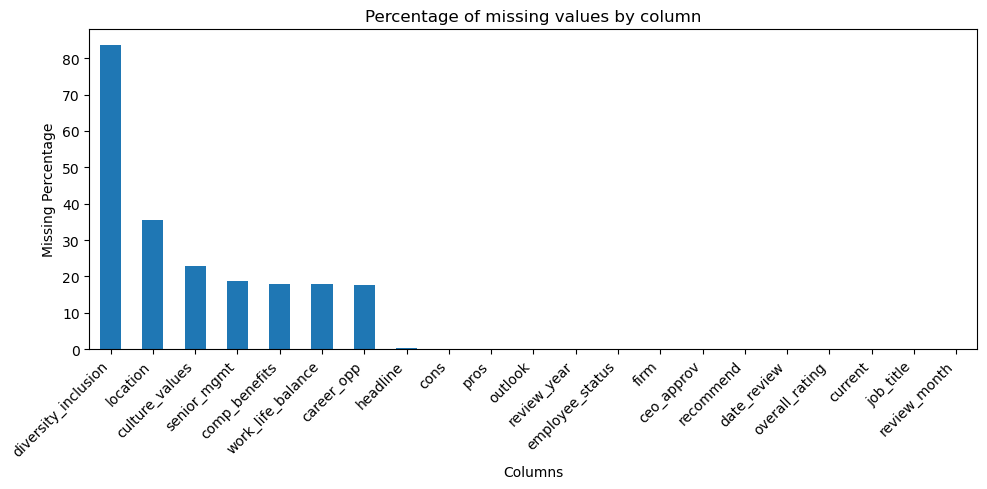

In [29]:
plt.figure(figsize = (10, 5))
missing_summary['missing_percentage'].plot(kind = 'bar')
plt.title('Percentage of missing values by column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

The missing-value summary confirms that missingness is concentrated in a limited number of variables. In particular, **diversity_inclusion** contains a very high proportion of missing values, while **location** also shows substantial missingness. By contrast, the core rating variables and the main text fields are relatively complete. These results suggest that the missing-value treatment should be performed selectively rather than uniformly accross all columns.

#### Missing Value Treatment Decisions

#### Diversity Inclusion

In [30]:
glassdoor_reviews['diversity_inclusion'].isna().sum()

np.int64(674160)

In [31]:
glassdoor_reviews['diversity_inclusion'].value_counts(dropna=False).sort_index()

diversity_inclusion
1.0      8194
2.0      8223
3.0     21760
4.0     34606
5.0     58108
NaN    674160
Name: count, dtype: int64

In [32]:
glassdoor_reviews['diversity_inclusion'].describe().T

count    130891.000000
mean          3.964245
std           1.193159
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: diversity_inclusion, dtype: float64

In [33]:
glassdoor_reviews.groupby(glassdoor_reviews['diversity_inclusion'].isna())['overall_rating'].agg(['count', 'mean', 'median'])

,count,mean,median
diversity_inclusion,,,
False,130891,3.820118,4.0
True,674160,3.625243,4.0


In [34]:
pd.crosstab(glassdoor_reviews['employee_status'],
            glassdoor_reviews['diversity_inclusion'].isna(), normalize = 'index')

diversity_inclusion,False,True
employee_status,,
Current,0.164578,0.835422
Former,0.159778,0.840222


In [35]:
pd.crosstab(glassdoor_reviews['review_year'],
            glassdoor_reviews['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_year,,
2008,0,5351
2009,0,5671
2010,0,9528
2011,0,10328
2012,0,19500
2013,0,23582
2014,0,37883
2015,0,66393
2016,0,80977


In [36]:
diversity_2020 = glassdoor_reviews[glassdoor_reviews['review_year']==2020].copy()
pd.crosstab(diversity_2020['review_month'], diversity_2020['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_month,,
1,0,8527
2,0,8168
3,0,6152
4,0,5788
5,0,6893
6,0,7891
7,0,8102
8,4,14808
9,1372,15597


In [37]:
diversity_2021 = glassdoor_reviews[glassdoor_reviews['review_year']==2021].copy()
pd.crosstab(diversity_2021['review_month'], diversity_2021['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_month,,
1,21412,10500
2,19772,8063
3,20304,8658
4,17082,7712
5,15448,7186
6,1911,967


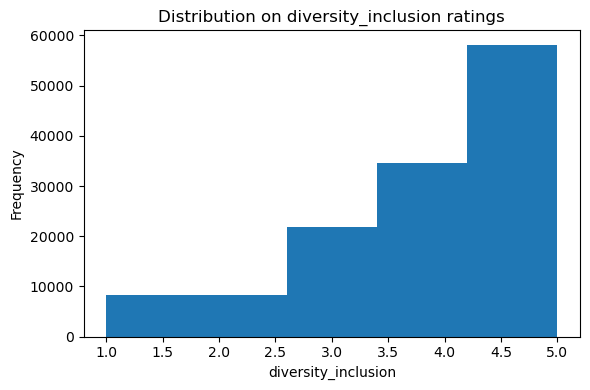

In [38]:
plt.figure(figsize = (6,4))
glassdoor_reviews['diversity_inclusion'].dropna().plot(kind = 'hist', bins = 5)
plt.title('Distribution on diversity_inclusion ratings')
plt.xlabel('diversity_inclusion')
plt.tight_layout()
plt.show()

The analysis of **diversity_inclusion** shows that this variable contains a very high proportion of missing values, with approximately 84% of observation lacking a recorded rating. Among the available values, the distribution is concentrated towards the upper end of the scale, with ratings of 4 and 5 being the most common. The descriptive statistics also indicate a relatively positive distribution with mean 3.96 and median 4.\
Further inspection suggest that the missingness is not random. Cross-tabulation by review year shows that the variable is entirely missing in earlier years and begins to appear only in more recent observations(2020 and 2021), which indicates that this rating was most likely introduced later. More detailed monthly analysis for 2020 and 2021 shows that the variable is available from August 2020 until June 2021. In August 2020 we have only 4 observations, after that non-missing values begin to increase noticeably in September and become much more common from October onward. By contrast, missingness does not differ substantially between current and former employees.\
Because of its very high and structually patterned missingness, **diversity_inclusion** is not suitable for use as a core variable in the main analysis. However, the available non-missing values may still be used for limited supplementary interpretation treated with caution.

#### Location

In [39]:
glassdoor_reviews['location'].isna().sum()

np.int64(285095)

In [40]:
glassdoor_reviews['location'].isna().sum()/len(glassdoor_reviews['location']) * 100

np.float64(35.41328437577247)

In [41]:
glassdoor_reviews['location'].value_counts(dropna=False)

location
NaN                                 285095
London, England, England             57341
New York, NY                         30090
Bangalore                            25672
Hyderābād                            10603
                                     ...  
Honiara                                  1
Aghia Paraskevi                          1
Kishangarh, Rajasthan, Rajasthan         1
Kampung Joh                              1
Wijnegem, Antwerp                        1
Name: count, Length: 14487, dtype: int64

In [42]:
glassdoor_reviews['location'].value_counts(dropna=False).head(20)

location
NaN                             285095
London, England, England         57341
New York, NY                     30090
Bangalore                        25672
Hyderābād                        10603
Mumbai                            9120
Gurgaon, Haryana, Haryana         8059
Chicago, IL                       7512
Singapore                         7266
San Francisco, CA                 7046
Dublin, Dublin                    6997
Redmond, WA                       6807
Pune                              6390
Toronto, ON                       6381
Manchester, England, England      5539
Dallas, TX                        4551
Sydney                            4530
Los Angeles, CA                   4167
Boston, MA                        4131
Birmingham, England, England      4076
Name: count, dtype: int64

In [43]:
glassdoor_reviews['location'].describe()

count                       519956
unique                       14486
top       London, England, England
freq                         57341
Name: location, dtype: object

In [44]:
pd.crosstab(glassdoor_reviews['review_year'],
            glassdoor_reviews['location'].isna(), normalize='index').round(3)

location,False,True
review_year,,
2008,0.932,0.068
2009,0.721,0.279
2010,0.628,0.372
2011,0.605,0.395
2012,0.684,0.316
2013,0.696,0.304
2014,0.663,0.337
2015,0.607,0.393
2016,0.593,0.407


In [45]:
pd.crosstab(glassdoor_reviews['employee_status'], 
            glassdoor_reviews['location'].isna(), normalize = 'index').round(3)

location,False,True
employee_status,,
Current,0.663,0.337
Former,0.622,0.378


In [46]:
glassdoor_reviews['location'].dropna().sample(20, random_state = 23).to_list()

['Palo Alto, CA',
 'Columbia, SC',
 'Walker, LA',
 'Indi, Karnataka, Karnataka',
 'Westford, MA',
 'Taipei',
 'New York, NY',
 'Swindon, Wiltshire, South West England, England, England',
 'Hyderābād',
 'Hyderābād',
 'London, England, England',
 'Boston, MA',
 'Seattle, WA',
 'The Colony, TX',
 'Athens',
 'Boston, MA',
 'Pune',
 'Bangalore',
 'Singapore',
 'New York, NY']

The analysis of **location** variable shows that it contains substanstial missingness with approximately 35.4% of values absent, as well as high cardinality with 14486 unique non-missing entires. Missingness is not constant over time, which suggests differences in data completeness across review years. At the same time, the non-missing values clearly contain meaningful geographic information. However, the formatting is highly inconsistent, with some entries recorded as cities, others as city-state pairs, and others as longer multi-level strings. For this reason, the raw **location** field is not suitable for direct use in the main analysis and should instead be treated as a candidate for simplified feature engineering, such as deriving an estimated country or restricting analysis to the most frequent locations.

In [47]:
glassdoor_reviews['location'].dropna().str.count(',').value_counts().sort_index()

location
0    133172
1    215471
2    161317
3      8260
4      1733
5         3
Name: count, dtype: int64

In [48]:
glassdoor_reviews['estimated_country']=glassdoor_reviews['location'].str.split(',').str[-1].str.strip()

In [49]:
glassdoor_reviews['estimated_country'].value_counts().head(20)

estimated_country
England      134416
NY            35052
CA            30535
Bangalore     25672
TX            15876
WA            12037
Hyderābād     10603
Scotland      10249
IL             9835
ON             9764
Mumbai         9120
FL             8882
Haryana        8081
Singapore      7266
Dublin         7052
MA             6409
Pune           6390
GA             5515
PA             5447
MI             4767
Name: count, dtype: int64

In [50]:
glassdoor_reviews = glassdoor_reviews.rename(columns = {'estimated_county':'location_last_part'})

The **location** variable contains potentially valuable geographic information, but its inconsistent formatting prevents straightforward use in the current preprocessing stage. A more refined geographic standardization may be considered later in the project as an optimal feauture-engineering step.

#### Headline

In [51]:
glassdoor_reviews['headline'].isna().sum()

np.int64(2451)

In [52]:
glassdoor_reviews['headline'].isna().sum() / len(glassdoor_reviews['headline']) * 100

np.float64(0.3044527613778506)

In [53]:
glassdoor_reviews['headline'].value_counts(dropna=False).head(20)

headline
Good                         13708
Great place to work          10924
Great                         6071
Great company                 5952
Good place to work            5812
Good company                  5413
Great Company                 4374
Review                        3908
good                          3762
Manager                       3447
Great company to work for     2723
Good Company                  2589
Analyst                       2571
NaN                           2451
Associate                     2436
Consultant                    2336
Ok                            2201
Good company to work for      1731
Great Place to Work           1537
Great place                   1512
Name: count, dtype: int64

In [54]:
glassdoor_reviews['headline'].value_counts(dropna=False).head(20)

headline
Good                         13708
Great place to work          10924
Great                         6071
Great company                 5952
Good place to work            5812
Good company                  5413
Great Company                 4374
Review                        3908
good                          3762
Manager                       3447
Great company to work for     2723
Good Company                  2589
Analyst                       2571
NaN                           2451
Associate                     2436
Consultant                    2336
Ok                            2201
Good company to work for      1731
Great Place to Work           1537
Great place                   1512
Name: count, dtype: int64

In [55]:
glassdoor_reviews['headline'].nunique()

390454

In [56]:
(glassdoor_reviews['headline'].fillna('').str.strip() == '').sum()

np.int64(2451)

In [57]:
glassdoor_reviews['headline_clean'] = glassdoor_reviews['headline'].fillna('').str.strip().str.lower()

In [58]:
glassdoor_reviews['headline_clean'].value_counts().head(20)

headline_clean
good                         17671
great place to work          14521
great company                11049
good company                  8992
good place to work            7411
great                         7301
review                        4698
ok                            3841
manager                       3828
great company to work for     3654
analyst                       2861
associate                     2641
consultant                    2573
                              2451
great place                   2348
good company to work for      2248
good experience               2233
great experience              1963
cashier                       1816
okay                          1690
Name: count, dtype: int64

In [59]:
glassdoor_reviews['headline_clean'].nunique()

361834

In [60]:
glassdoor_reviews['headline_word_count']=glassdoor_reviews['headline_clean'].str.split().str.len()
glassdoor_reviews['headline_word_count'].describe()

count    805051.000000
mean          3.905495
std           3.177254
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          93.000000
Name: headline_word_count, dtype: float64

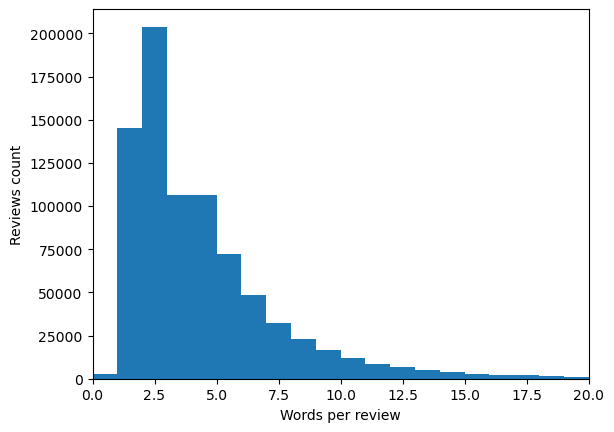

In [61]:
plt.hist(glassdoor_reviews['headline_word_count'], bins = 'fd')
plt.xlabel('Words per review')
plt.ylabel('Reviews count')
plt.xlim(0, 20)
plt.show()

The **headline** variable contains very little missing data and is therefore suitable for further analysis, After basic text normalization, including whitespace trimming and conversion to lowercase, the number of unique values decreased from 390454 to 361834, which indicates  that a substantial part of the variation was caused by inconsistent capitalization and formatting. The most frequent cleaned headlines are short evaluative phrases such as **good, great place to work, great compay**, suggesting that the column captures brief summaries of employee sentiment. At the same time, some common entires, such as **manager, analyst, consultant, review** appear to be generic or weakly informative. Overall, the column is retained for later text analysis, with the cleaned version used in preference to the raw text. Additional inspection of headline length shows that most headlines are short, which is consistent with their role as brief review summaries rather than detailed textual feedback.

#### Pros

In [62]:
glassdoor_reviews['pros'].isna().sum()

np.int64(2)

In [63]:
glassdoor_reviews['pros'].isna().sum() / len(glassdoor_reviews['pros']) * 100

np.float64(0.0002484314658325994)

In [64]:
glassdoor_reviews[glassdoor_reviews['pros'].isna()]

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,outlook,headline,pros,cons,employee_status,review_year,review_month,estimated_country,headline_clean,headline_word_count
34,AFH-Wealth-Management,2019-05-02,Anonymous Employee,"Former Employee, less than 1 year",NaN,1,1.0,1.0,NaN,1.0,...,No opinion,Horrible,NaN,Training is rush not a nice environment too ma...,Former,2019,5,NaN,horrible,1
600548,Morrisons,2018-11-18,Operations,"Former Employee, more than 10 years","London, England, England",1,1.0,1.0,NaN,1.0,...,Negative,Morrisons current success with financials is n...,NaN,Since appointment of complete new senior leade...,Former,2018,11,England,morrisons current success with financials is n...,12


The two missing observations in the **pros** field belong to former employees and are accompanied with clearly negative headlines and critical **cons** text. This suggests  that the absence of recorded positive comments in these cases is likely consistent with strongly unfavorable review experiences rather that being the result of random missingness.

In [65]:
glassdoor_reviews['pros'].value_counts(dropna=False).head(20)

pros
Great company to work for     697
Good company to work for      567
Great people to work with     490
Work life balance is good     439
Good people to work with      292
Good company to work with     239
Great company to work for.    216
work life balance is good     189
good company to work for      188
great company to work for     186
Great place to work at        173
Nice people to work with      166
Good company to work for.     124
Work life balance is great    119
Good place to work at         116
Great people to work with.    113
Great team to work with       106
Great Company to work for      94
Work life balance is good.     86
great people to work with      86
Name: count, dtype: int64

In [66]:
glassdoor_reviews['pros'].nunique()

778559

In [67]:
glassdoor_reviews['pros_clean'] = glassdoor_reviews['pros'].fillna('').str.strip().str.lower()

In [68]:
glassdoor_reviews['pros_clean'].value_counts().head(20)

pros_clean
great company to work for      990
good company to work for       819
work life balance is good      721
great people to work with      605
good people to work with       377
good company to work with      354
great company to work for.     270
great place to work at         241
nice people to work with       235
very good work life balance    183
work life balance is great     181
good place to work at          166
good company to work for.      154
very good place to work        137
great team to work with        134
good good good good good       128
great people to work with.     124
work life balance is good.     122
none that i can think of       119
great company to work with     118
Name: count, dtype: int64

In [69]:
glassdoor_reviews['pros_clean'].nunique()

772458

In [70]:
glassdoor_reviews['pros_clean'] = glassdoor_reviews['pros_clean'].str.replace(r'.','')

In [71]:
glassdoor_reviews['pros_clean'].value_counts().head(20)

pros_clean
great company to work for        1263
good company to work for          980
work life balance is good         845
great people to work with         730
good people to work with          428
good company to work with         424
great place to work at            294
nice people to work with          265
work life balance is great        208
very good work life balance       200
good place to work at             195
none that i can think of          164
great team to work with           161
great company to work with        153
very good place to work           149
great place to work for           146
good good good good good          128
good environment to work in       127
good work and life balance        127
very good company to work for     116
Name: count, dtype: int64

In [72]:
glassdoor_reviews['pros_clean'].nunique()

768619

In [73]:
(glassdoor_reviews['pros_clean'].str.strip() == '').sum()

np.int64(6)

In [74]:
glassdoor_reviews['pros_word_count'] = glassdoor_reviews['pros_clean'].str.split().str.len()
glassdoor_reviews['pros_word_count'].describe()

count    805051.000000
mean         14.925925
std          19.684972
min           0.000000
25%           6.000000
50%           9.000000
75%          17.000000
max        3153.000000
Name: pros_word_count, dtype: float64

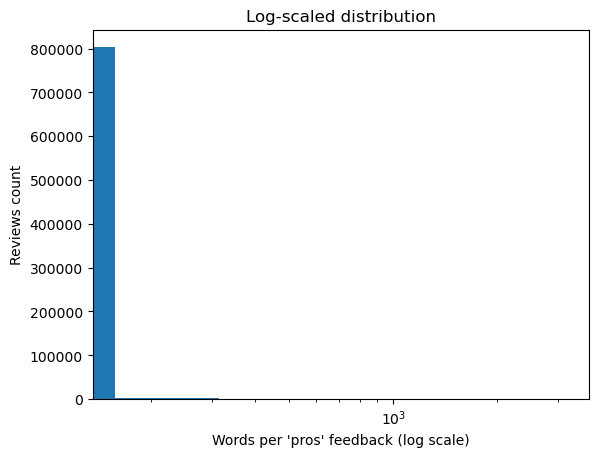

In [75]:
plt.hist(glassdoor_reviews['pros_word_count'], bins = 20)
plt.xscale('log')
plt.xlabel('Words per \'pros\' feedback (log scale)')
plt.ylabel('Reviews count')
plt.title('Log-scaled distribution')
plt.show()

In [76]:
q99 = glassdoor_reviews['pros_word_count'].quantile(0.99)

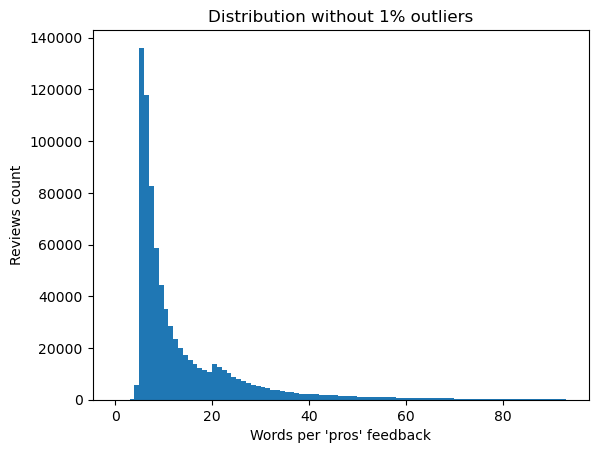

In [77]:
q99_pros_word_counts = glassdoor_reviews[glassdoor_reviews['pros_word_count'] <= q99]
plt.hist(q99_pros_word_counts['pros_word_count'], bins = 'fd')
plt.xlabel('Words per \'pros\' feedback')
plt.ylabel('Reviews count')
plt.title('Distribution without 1% outliers')
plt.show()

Initial inspection showed that raw **pros** text contains many repeated positive phrases, but also inconsistency in capitalization and punctuation, To improve comparability, a cleaned version called **pros_clean** was created by trimming whitespace, converting text to lowercase and removing periods. This reduced the number of unique values from 778559 to 768619, indicating that part of the variation in the raw text was due to formatting rather than meaning. The most frequent cleaned entries include phrases such as *great company to work for, good company to work for, work life balance is good* suggesting that the field captures short positive summaries of employee experience. In terms of length, the texts are generally short to medium-length: the median entry contains 9 words, while 75% contain 17 words or fewer. At the same time, the distribution is strongly right-skewed, with a small number of very long comments acting as outliers.

#### Cons

In [78]:
glassdoor_reviews['cons'].isna().sum()

np.int64(13)

In [79]:
glassdoor_reviews['cons'].isna().sum() / len(glassdoor_reviews['cons']) * 100

np.float64(0.0016148045279118963)

In [80]:
glassdoor_reviews[glassdoor_reviews['cons'].isna()]

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,pros,cons,employee_status,review_year,review_month,estimated_country,headline_clean,headline_word_count,pros_clean,pros_word_count
17069,American-Express,2016-05-30,,Current Employee,"Gurgaon, Haryana, Haryana",4,NaN,NaN,NaN,NaN,...,Great place to work and enough opportunites in...,NaN,Current,2016,5,Haryana,director,1,great place to work and enough opportunites in...,10
62585,BNP-Paribas,2015-12-03,GECD Middle Office Trade Support,"Current Employee, more than 5 years",Paris,4,NaN,NaN,NaN,NaN,...,"Great benefits, great work atmosphere",NaN,Current,2015,12,Paris,assistant vice president,3,"great benefits, great work atmosphere",5
197269,Deloitte,2019-07-18,Associate Analyst,"Current Employee, more than 1 year",Hyderābād,5,5.0,5.0,NaN,5.0,...,we get to work with different technologies and...,NaN,Current,2019,7,Hyderābād,great experience for a fresher,5,we get to work with different technologies and...,11
244086,EY,2017-02-07,,Current Employee,NaN,5,4.0,5.0,NaN,5.0,...,Great People and interesting work,NaN,Current,2017,2,NaN,"great place to work, learn, and develop",7,great people and interesting work,5
253772,EY,2019-09-17,Senior Consultant,"Former Employee, more than 3 years",Koch,5,4.0,4.0,NaN,4.0,...,"Good working Environment, Lots of new technol...",NaN,Former,2019,9,Koch,senior consultant,2,"good working environment, lots of new technol...",16
302805,Grant-Thornton,2016-02-23,Senior Associate,"Former Employee, less than 1 year","Markham, ON",3,2.0,3.0,NaN,3.0,...,great for some one who's looking to gain a cou...,NaN,Former,2016,2,ON,"location - gurgaon, india",4,great for some one who's looking to gain a cou...,16
494186,Marriott-International,2016-10-21,Anonymous Employee,Former Employee,NaN,5,4.0,5.0,NaN,5.0,...,"Great company with a great product, best in th...",NaN,Former,2016,10,NaN,chief engineer,2,"great company with a great product, best in th...",10
609170,National-Star,2017-02-11,Apprentice,Current Employee,"Gloucester, England, England",5,5.0,5.0,NaN,5.0,...,"Great staff, management are good and always pl...",NaN,Current,2017,2,England,awesome!,1,"great staff, management are good and always pl...",15
612570,Northern-Gas-and-Power,2020-02-03,Customer Service Manager,"Current Employee, more than 3 years","Newcastle upon Tyne, England, England",5,5.0,5.0,NaN,5.0,...,"Amazing incentives, great working vibe, quarte...",NaN,Current,2020,2,England,best place to work,4,"amazing incentives, great working vibe, quarte...",25
720350,SAP,2018-04-11,Anonymous Employee,Current Employee,NaN,5,4.0,4.0,NaN,4.0,...,"Peace,Fair,competitive salary; Career Opportun...",NaN,Current,2018,4,NaN,solution sales,2,"peace,fair,competitive salary; career opportun...",5


The 13 missing observations in the **cons** field belong to mostly surrent employees and are accompanied with clearly positive headlines and favorable **pros** text. This suggests  that the absence of recorded negative comments in these cases is likely consistent with strongly favorable review experiences rather that being the result of random missingness.

In [81]:
glassdoor_reviews['cons'].value_counts(dropna=False).head(20)

cons
None that I can think of         1128
None that I can think of.         432
None I can think of               332
Nothing I can think of            230
Long hours during busy season     214
none that I can think of          205
none that i can think of          187
Nothing that I can think of       171
No cons as of now                 165
None none none none none          137
None that i can think of          128
I can't think of any              116
No cons that I can think of       109
Lack of work life balance         106
none none none none none          106
I don't have any cons             102
No work life balance at all       100
None that come to mind            100
Can't think of any cons            95
None I can think of.               79
Name: count, dtype: int64

In [82]:
glassdoor_reviews['cons'].nunique()

777133

In [83]:
glassdoor_reviews['cons_clean'] = glassdoor_reviews['cons'].fillna('').str.strip().str.lower().str.replace(r'.','')

In [84]:
glassdoor_reviews['cons_clean'].value_counts(dropna=False).head(20)

cons_clean
none that i can think of         2165
none i can think of               592
nothing i can think of            449
none none none none none          363
nothing that i can think of       353
no cons as of now                 306
long hours during busy season     293
no cons that i can think of       233
i can't think of any              198
none that come to mind            180
lack of work life balance         174
no work life balance at all       167
i don't have any cons             164
can't think of any cons           163
no cons i can think of            141
none, none, none, none, none      124
no cons at this time              118
i do not have any cons            116
there is no work life balance     114
can be stressful at times         113
Name: count, dtype: int64

In [85]:
glassdoor_reviews['cons_clean'].nunique()

767337

In [86]:
(glassdoor_reviews['cons_clean'].str.strip() == '').sum()

np.int64(78)

In [87]:
glassdoor_reviews.loc[
    glassdoor_reviews['cons_clean'].str.strip() == '',
    ['cons']
].head(20)

,cons
10251,. . . . .
17069,NaN
21510,......... ...... ...... ...... .......
22260,. . . . .
25676,..................... .................. ........
25847,. . . . .
50525,. . . . . . .
52824,. . . . .
62585,NaN
92256,. . . . .


After cleaning, 78 entries became empty strings. Inspection of these cases showed that they consist not only of truly missing values, but also of non-informative placeholders made up of punstuation only. This suggests that a small number of **cons** responses do not contain meaningful textual content even when the original fields is technically non-null.

In [88]:
glassdoor_reviews['cons_word_count'] = glassdoor_reviews['cons_clean'].str.split().str.len()
glassdoor_reviews['cons_word_count'].describe()

count    805051.000000
mean         21.024800
std          39.919569
min           0.000000
25%           6.000000
50%           9.000000
75%          21.000000
max        1917.000000
Name: cons_word_count, dtype: float64

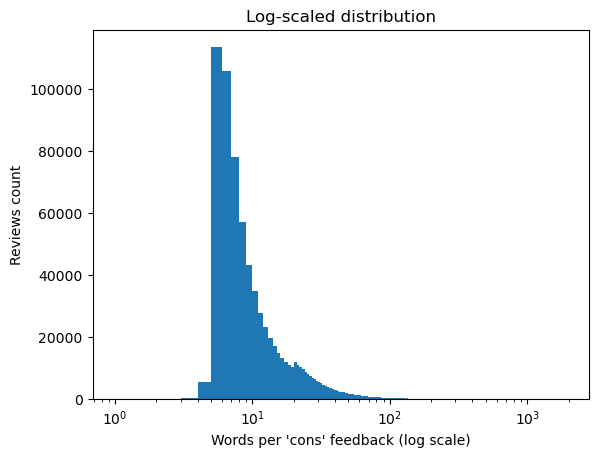

In [89]:
plt.hist(glassdoor_reviews['cons_word_count'], bins = 'fd')
plt.xscale('log')
plt.xlabel('Words per \'cons\' feedback (log scale)')
plt.ylabel('Reviews count')
plt.title('Log-scaled distribution')
plt.show()

In [90]:
q99 = glassdoor_reviews['cons_word_count'].quantile(0.99)

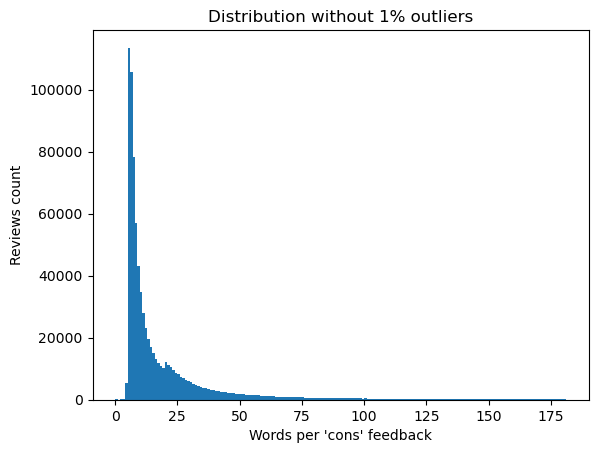

In [91]:
q99_cons_word_counts = glassdoor_reviews[glassdoor_reviews['cons_word_count'] <= q99]
plt.hist(q99_cons_word_counts['cons_word_count'], bins = 'fd')
plt.xlabel('Words per \'cons\' feedback')
plt.ylabel('Reviews count')
plt.title('Distribution without 1% outliers')
plt.show()

The raw **cons** field contains very little missing data and is therefor suitable for text analysis. After the missing cases and the small number of non-informative cleaned entries were inspected seperately, a ckeaned version called **cons_cleaned** was created by trimming whitespace, converting text to lowercase and removing periods. This reduced the number of unique values from 777133 to 767337, indicating that part of the variation in the raw text was due to formatting rather that meaning. The most frequent cleaned entries incluse phrases like *none that i can think of, nothing i can thing of, none cons as of now*, which suggests that many reviews report few or no major disadvantages. In terms of length, the texts are generally short to medium-length: the median entry contains 9 words, while 75% contain 21 words or fewer. At the same time, the distribution is strongly right-skewed, with a small number of very long comments acting as outliers. Overall, the **cons** field is retained as an important text variable and the cleaned version will be used in later analysis.

#### Comparison between Headline and Pros or Cons

In [92]:
headline_matches_pros = (
    (glassdoor_reviews['headline_clean'].str.strip() != '') &
    (glassdoor_reviews['pros_clean'].str.strip() != '') &
    (glassdoor_reviews['headline_clean'] == glassdoor_reviews['pros_clean'])
)

headline_matches_cons = (
    (glassdoor_reviews['headline_clean'].str.strip() != '') &
    (glassdoor_reviews['cons_clean'].str.strip() != '') &
    (glassdoor_reviews['headline_clean'] == glassdoor_reviews['cons_clean'])
)

print("Headline = Pros:", headline_matches_pros.sum(), round(headline_matches_pros.mean() * 100, 2))
print("Headline = Cons:", headline_matches_cons.sum(), round(headline_matches_cons.mean() * 100, 2))

Headline = Pros: 1683 0.21
Headline = Cons: 206 0.03


A brief comparison between the cleaned **headline** field and cleaned **pros** and **cons** fields shows that exact duplication is rare. Only 1683 observations (0.21%) contain identical text in both **headline** and **pros**, while only 206 observations (0.03%) show exact overlap between **headline** and **cons**. This suggests that the headline usually provides at least partly distinct information rather than simply repeating the main positive or negative feeback fields.

#### Numeric variables

Several core rating variables, including **culture_values, senior_mgmt, comp_benefits, work_life_balance, career_opp**, contain moderate missingness. Unlike the text-based and high-cardinality fields discussed earlier, these variables are numeric, structurally consistent, and measured on the same rating scale. For this reason, they are retained for analysis, while missing values are handled by case-wise exclusion where necessary rather than through separate variable-specific preprocessing.

In [93]:
core_rating_columns = [
    'overall_rating', 'work_life_balance', 'culture_values',
    'career_opp', 'comp_benefits', 'senior_mgmt'
]

glassdoor_reviews[core_rating_columns].isna().mean().sort_values(ascending=False) * 100

culture_values       22.776694
senior_mgmt          18.608014
comp_benefits        17.917126
work_life_balance    17.894518
career_opp           17.604599
overall_rating        0.000000
dtype: float64

In [94]:
glassdoor_reviews[core_rating_columns].describe()

,overall_rating,work_life_balance,culture_values,career_opp,comp_benefits,senior_mgmt
count,805051.000000,660991.000000,621687.000000,663325.000000,660809.000000,655247.000000
mean,3.656927,3.374736,3.590585,3.458933,3.402215,3.178473
std,1.177071,1.306846,1.325257,1.274151,1.220950,1.332946
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000
75%,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Overall, the preprocessing stage showed that the dataset is rich and informative, but also contains important quality issues related to missingness, duplicates, encoded categories and incosistent text formatting. After cleaning and deriving several auxiliary variables, the data is now in a more reliable form for exploratory and comparative analysis. Since the numeric variables form the core of structured review information, the exploratory analysis with their distribution and relationships, with particular attention to **overall_rating** as the central measure of employee evaluation.

## Exploratory Data Analysis

### Distribution of Core Rating Variables

After preprocessing and assessing data quality, the next step is to explore the main patterns in the cleaned dataset. The exploratory analysis focuses first on the structured rating variables and then on different across employee groups and textual feedback fields.

In [95]:
glassdoor_reviews['overall_rating'].value_counts().sort_index()

overall_rating
1     56998
2     71812
3    185745
4    266324
5    224172
Name: count, dtype: int64

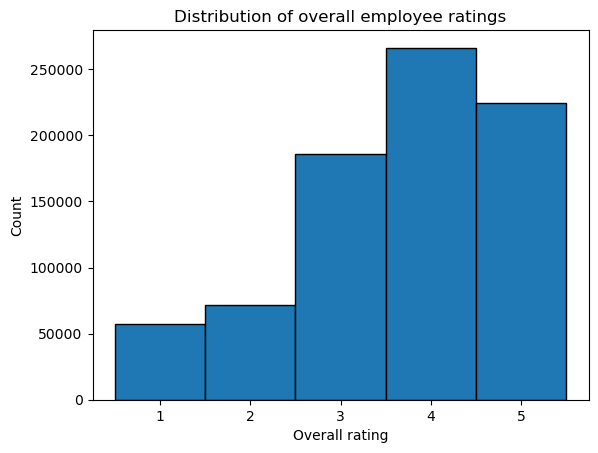

In [96]:
plt.hist(glassdoor_reviews['overall_rating'], bins = np.arange(0.5, 6.5, 1), edgecolor = 'black')
plt.xlabel("Overall rating")
plt.ylabel("Count")
plt.title("Distribution of overall employee ratings")
plt.show()

The distribution of **overall_rating** is clearly concentrated toward the upper end of five-point scale. Rating of 4 and 5 are the most common, while low ratings of 1 and 2 appear much less frequently. The single most frequent value is 4, which suggests that the employee evaluations in the dataset are more positive than negative. At the same time, the presence of a substantial number of 1, 2, 3star reviews, indicates that the dataset still contains meaningful variation and is not limited only to highly favorable opinions.

In [97]:
for col in core_rating_columns:
    if col != "overall_rating":
        print(glassdoor_reviews[col].value_counts().sort_index())

work_life_balance
1.0     78473
2.0     89052
3.0    162297
4.0    168643
5.0    162526
Name: count, dtype: int64
culture_values
1.0     68351
2.0     63225
3.0    125522
4.0    162092
5.0    202497
Name: count, dtype: int64
career_opp
1.0     67819
2.0     82196
3.0    161485
4.0    181394
5.0    170431
Name: count, dtype: int64
comp_benefits
1.0     60108
2.0     88764
3.0    181180
4.0    186747
5.0    144010
Name: count, dtype: int64
senior_mgmt
1.0    104278
2.0     94139
3.0    164284
4.0    165453
5.0    127093
Name: count, dtype: int64


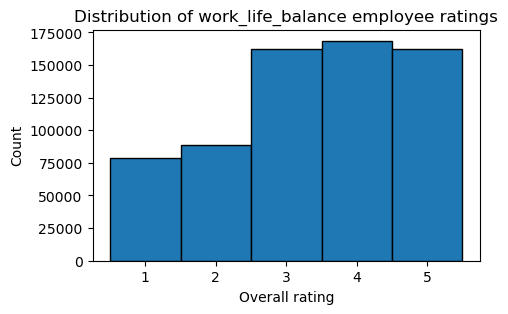

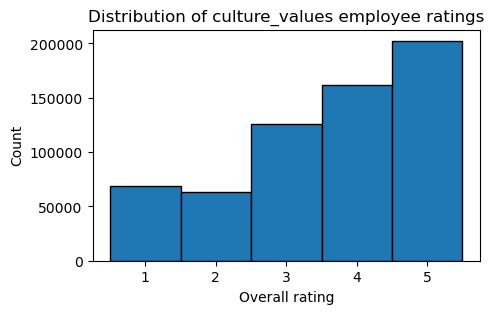

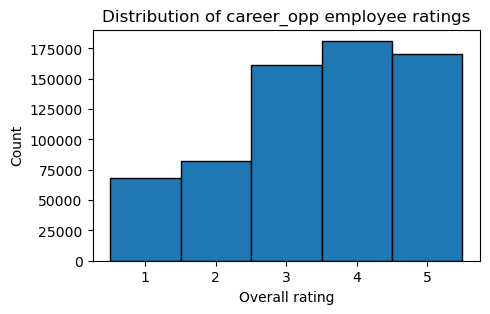

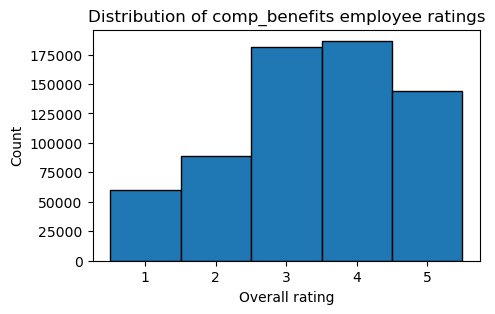

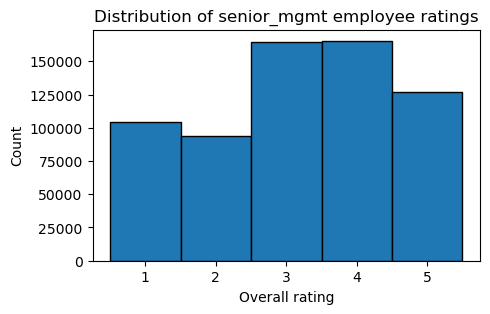

In [98]:
for col in core_rating_columns:
    if col != "overall_rating":
        plt.figure(figsize=(5, 3))
        plt.hist(glassdoor_reviews[col].dropna(), bins = np.arange(0.5, 6.5, 1), edgecolor = 'black')
        plt.xlabel("Overall rating")
        plt.ylabel("Count")
        plt.title(f"Distribution of {col} employee ratings")
        plt.show()

The core rating variables follow a similar pattern to **overall_rating**, with most values concentrated at the higher end of the five-point scale. Ratings of 3, 4, and 5 are much more common than 1 and 2, which suggests that employee evaluations are generally more positive than negative.

### Overall Rating by Employee Status

In [99]:
glassdoor_reviews['employee_status'].value_counts()

employee_status
Current    471188
Former     333863
Name: count, dtype: int64

In [100]:
glassdoor_reviews.groupby('employee_status')[core_rating_columns].mean()

,overall_rating,work_life_balance,culture_values,career_opp,comp_benefits,senior_mgmt
employee_status,,,,,,
Current,3.811929,3.514512,3.781097,3.617634,3.492648,3.352758
Former,3.438171,3.172736,3.320089,3.229958,3.271617,2.926186


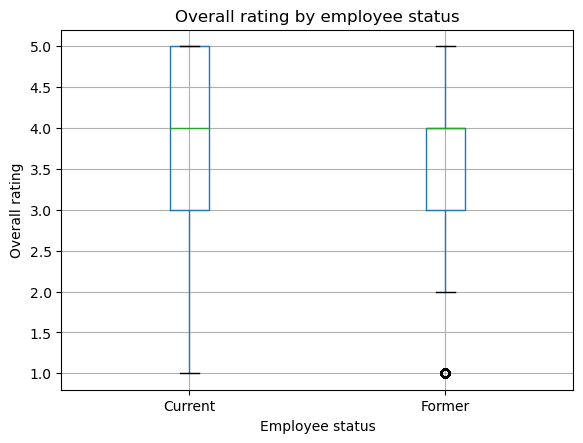

In [101]:
glassdoor_reviews.boxplot(column='overall_rating', by='employee_status')
plt.title('Overall rating by employee status')
plt.suptitle('')
plt.xlabel('Employee status')
plt.ylabel('Overall rating')
plt.show()

The comparison between employee status shows a clear difference between current and former employees. Current employees report higher average scores across all core rating variables, including **overall_rating, work_life_balance, vulture_values, career_opp, comp_benefits, senior_mgmt**. The largest gap appears to be in **senior_mgmt**, while **career_opp** shows the smallest difference. The boxplot for **overall_rating** confirms this pattern: current employees have a higher central tendency, whereas former employees are more concentrated in lower values. Overall, this suggests that former employees tend to evaluate their workplace less favorably than current employees.

### Relationships between Rating Values

In [102]:
glassdoor_reviews[core_rating_columns].corr()

,overall_rating,work_life_balance,culture_values,career_opp,comp_benefits,senior_mgmt
overall_rating,1.000000,0.565493,0.767080,0.715612,0.611349,0.752500
work_life_balance,0.565493,1.000000,0.555875,0.402242,0.436548,0.541908
culture_values,0.767080,0.555875,1.000000,0.641220,0.545943,0.746398
career_opp,0.715612,0.402242,0.641220,1.000000,0.563395,0.665906
comp_benefits,0.611349,0.436548,0.545943,0.563395,1.000000,0.544267
senior_mgmt,0.752500,0.541908,0.746398,0.665906,0.544267,1.000000


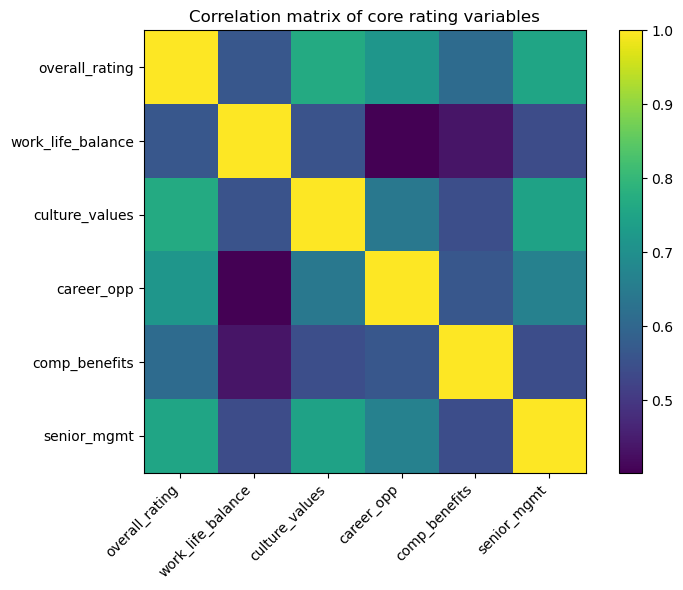

In [263]:
import matplotlib.pyplot as plt

corr = glassdoor_reviews[core_rating_columns].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation matrix of core rating variables')
plt.tight_layout()
plt.show()

The correlation analysis shows that all core variables are positively related to one another. *overall_rating* is most strongly associated with *culture_values* and *senior_mgmt*, followed closely by *career_opp*. This suggests that perception of company culture, management quality and career opportunities are closely linked to overall employee evaluations. By contrast, *work_life_balance* and *comp_benefits* still show meaningful positive relationshipt with *overall_rating* but the associations are weaker.

### Temporal Patterns in Reviews

In [104]:
glassdoor_reviews['review_year'].value_counts().sort_index()

review_year
2008      5351
2009      5671
2010      9528
2011     10328
2012     19500
2013     23582
2014     37883
2015     66393
2016     80977
2017     87567
2018     84591
2019     99340
2020    135325
2021    139015
Name: count, dtype: int64

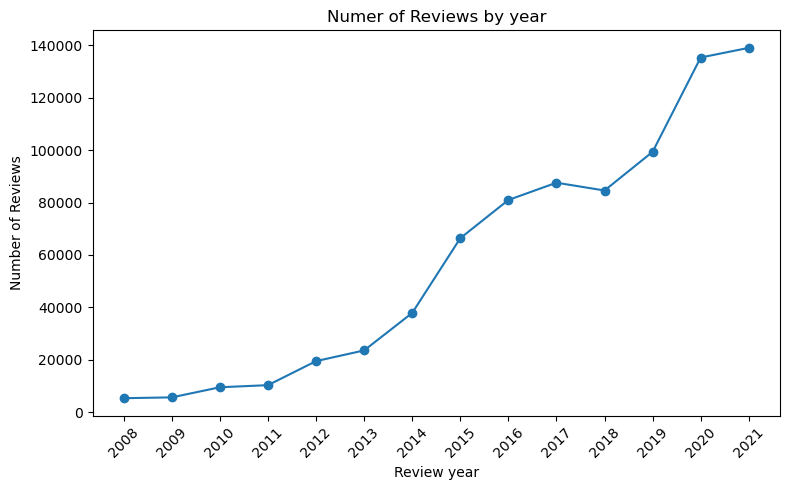

In [105]:
reviews_per_year = glassdoor_reviews['review_year'].value_counts().sort_index()

plt.figure(figsize = (8, 5))
plt.plot(reviews_per_year.index, reviews_per_year.values, marker = 'o')
plt.xlabel("Review year")
plt.ylabel("Number of Reviews")
plt.title("Numer of Reviews by year")
plt.xticks(reviews_per_year.index, rotation = 45)
plt.tight_layout()
plt.show()

The temporal analysis shows stron increase in the number of reviews over time. Review volume grows gradually from 2008 onward, accelerates after 2014 and reache its higher levels in 2020 and 2021. This suggests that the dataset becomes much denser in later years, which should be taken into account when interpreting time trends.

In [106]:
glassdoor_reviews.groupby('review_year')['overall_rating'].mean()

review_year
2008    3.454121
2009    3.268207
2010    3.205185
2011    3.285244
2012    3.508564
2013    3.468323
2014    3.404297
2015    3.494932
2016    3.573348
2017    3.600797
2018    3.638070
2019    3.673898
2020    3.846710
2021    3.836831
Name: overall_rating, dtype: float64

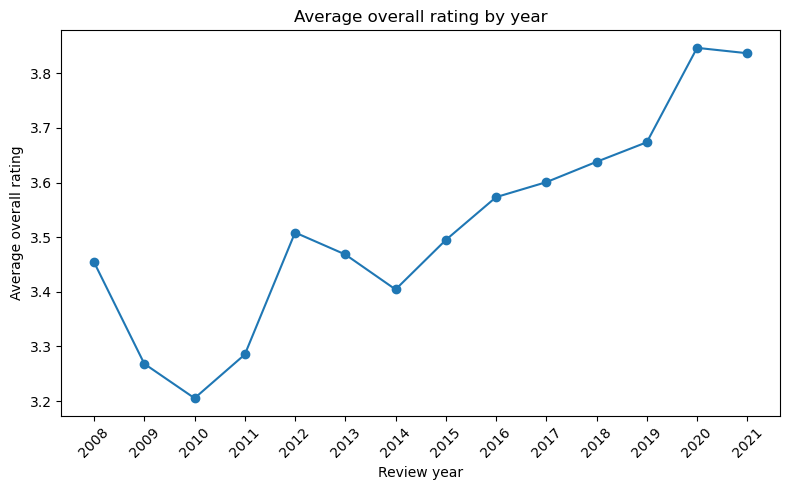

In [107]:
avg_rating_per_year = glassdoor_reviews.groupby('review_year')['overall_rating'].mean()

plt.figure(figsize = (8, 5))
plt.plot(avg_rating_per_year.index, avg_rating_per_year.values, marker = 'o')
plt.xlabel("Review year")
plt.ylabel("Average overall rating")
plt.title("Average overall rating by year")
plt.xticks(avg_rating_per_year.index, rotation = 45)
plt.tight_layout()
plt.show()

Average **overall_rating** also shows pward trend over time. After lower values in the early years, the mean rating increases gradually from around 2014 onward and reaches its highest levels in 2020 and 2021. This suggests that more recent reviews tend to be more favorable on average.

In [108]:
glassdoor_reviews.groupby(['review_year', 'employee_status'])['overall_rating'].mean().unstack()

employee_status,Current,Former
review_year,,
2008,3.582847,3.094326
2009,3.323355,3.164035
2010,3.229782,3.163410
2011,3.346086,3.165517
2012,3.602775,3.318259
2013,3.582997,3.280813
2014,3.519772,3.226593
2015,3.630654,3.310729
2016,3.725462,3.388046


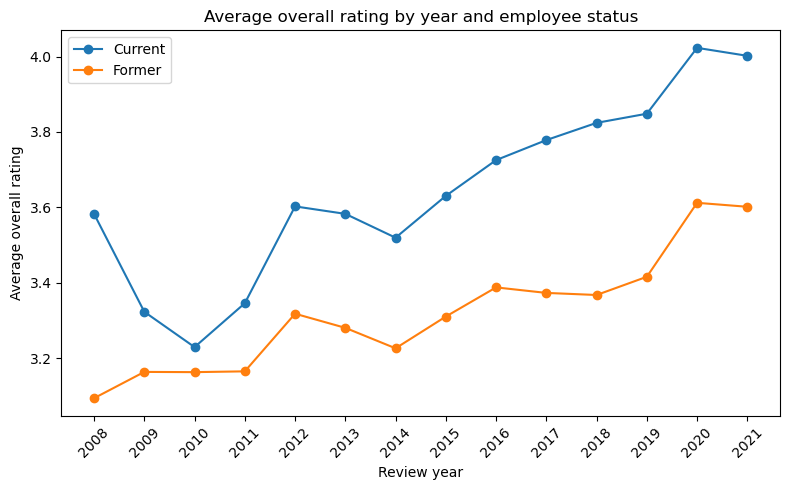

In [109]:
avg_rating_by_year_status = (glassdoor_reviews.groupby(['review_year','employee_status'])['overall_rating'].mean().unstack())

plt.figure(figsize = (8, 5))
for col in avg_rating_by_year_status.columns:
    plt.plot(avg_rating_by_year_status.index, avg_rating_by_year_status[col], marker = 'o', label = col)
    
plt.xlabel("Review year")
plt.ylabel("Average overall rating")
plt.title("Average overall rating by year and employee status")
plt.xticks(avg_rating_by_year_status.index, rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

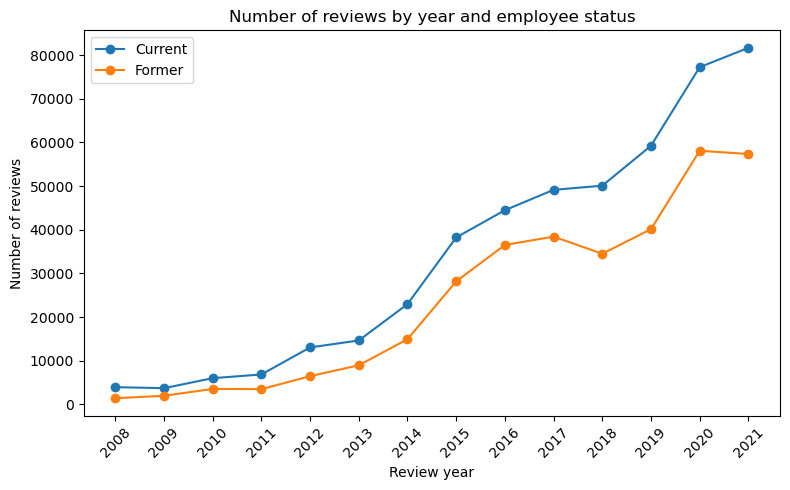

In [110]:
count_by_year_status = (glassdoor_reviews.groupby(['review_year','employee_status']).size().unstack())

plt.figure(figsize = (8, 5))
for col in count_by_year_status.columns:
    plt.plot(count_by_year_status.index, count_by_year_status[col], marker = 'o', label = col)
    
plt.xlabel("Review year")
plt.ylabel("Number of reviews")
plt.title("Number of reviews by year and employee status")
plt.xticks(count_by_year_status.index, rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

When the analysis is split by employee status, current employees constantly report higher average ratings than former employees in every year of the dataset. However, both groups follow similar upward trend over time with visible increase in later years. The number of reviews also rises for both groups, although current employees remain the larger group throughout the entire period.

### Textual Exploration of Pros and Cons

In addition to the structured rating variables, the dataset contains three important text fields: **headline, pros, cons**. These fields provide direct written summaries of employee experiences and therefore complement the numeric ratings. Since cleaned versions of these variables were created during preprocessing, the following exploratory analysis focuses on text length, overlap between fields and most common positive and negative expressions.\
Exact overlap between headline field and the main text fields is rare. Only a very small share of observations contain identical text in both *headline* and *pros* or in *headline* and *cons*, which suggests that the headline usually adds at least partly distinct information rather than simply repeating the longer feedback fields.

In [111]:
text_length_summary = pd.DataFrame({
    'headline_words': glassdoor_reviews['headline_word_count'].describe(),
    'pros_words': glassdoor_reviews['pros_word_count'].describe(),
    'cons_words': glassdoor_reviews['cons_word_count'].describe()
        })

text_length_summary

,headline_words,pros_words,cons_words
count,805051.000000,805051.000000,805051.000000
mean,3.905495,14.925925,21.024800
std,3.177254,19.684972,39.919569
min,0.000000,0.000000,0.000000
25%,2.000000,6.000000,6.000000
50%,3.000000,9.000000,9.000000
75%,5.000000,17.000000,21.000000
max,93.000000,3153.000000,1917.000000


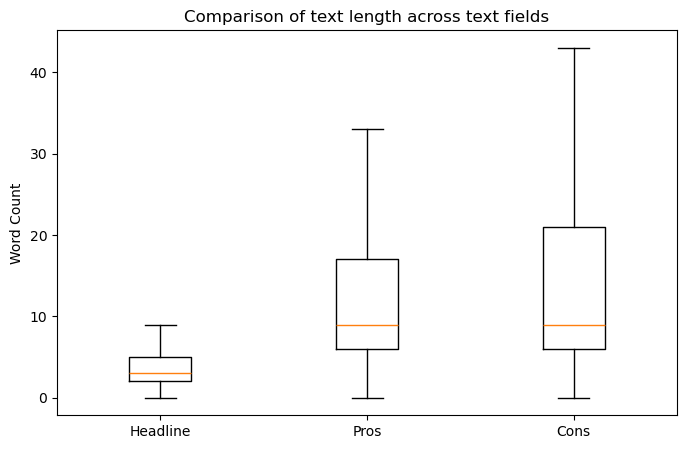

In [112]:
plt.figure(figsize = (8, 5))
plt.boxplot([
    glassdoor_reviews['headline_word_count'].dropna(),
    glassdoor_reviews['pros_word_count'].dropna(),
    glassdoor_reviews['cons_word_count'].dropna()], tick_labels = ['Headline', 'Pros', 'Cons'], showfliers = False)
plt.ylabel('Word Count')
plt.title('Comparison of text length across text fields')
plt.show()
    

The three text fields differ clearly in length. As expected, *headline* is the shortest field and functions mainly as brief summary, while *pros* and *cons* contain longer written comments. This confirms that the dataset provides both short-form and longer-form tetual information, which may capture different aspects of employee opinion.

In [113]:
glassdoor_reviews['pros_clean'].value_counts().head(15)

pros_clean
great company to work for      1263
good company to work for        980
work life balance is good       845
great people to work with       730
good people to work with        428
good company to work with       424
great place to work at          294
nice people to work with        265
work life balance is great      208
very good work life balance     200
good place to work at           195
none that i can think of        164
great team to work with         161
great company to work with      153
very good place to work         149
Name: count, dtype: int64

In [114]:
glassdoor_reviews['cons_clean'].value_counts().head(15)

cons_clean
none that i can think of         2165
none i can think of               592
nothing i can think of            449
none none none none none          363
nothing that i can think of       353
no cons as of now                 306
long hours during busy season     293
no cons that i can think of       233
i can't think of any              198
none that come to mind            180
lack of work life balance         174
no work life balance at all       167
i don't have any cons             164
can't think of any cons           163
no cons i can think of            141
Name: count, dtype: int64

The most frequent cleaned entires in **pros** are strongly positive phrases such as *great company to work for, good company to work for, work life balance is good*. By contrast, the most frequent entries in **cons** often indicate either the absence of strong ngative opinions or relatively mild criticism, with common phrases such as *none that i can think of, nothing i can think of, no cons as of now*. This suggests that the text fields are highly informative, but also that many employeessummarize their opinions using repeated expressions.

In [115]:
glassdoor_reviews[['pros_word_count', 'cons_word_count']].mean()

pros_word_count    14.925925
cons_word_count    21.024800
dtype: float64

In [116]:
glassdoor_reviews[['pros_word_count', 'cons_word_count']].median()

pros_word_count    9.0
cons_word_count    9.0
dtype: float64

A comparison of text length shows that **cons** tends to be slightly longer than **pros** on average. This may indicate that employees often provide more detailed explanation when describing negative aspects of work, even though many **cons** entries are still short.

In [117]:
glassdoor_reviews.groupby('employee_status')[['pros_word_count', 'cons_word_count']].mean()

,pros_word_count,cons_word_count
employee_status,,
Current,15.590728,19.503928
Former,13.987675,23.171238


In [118]:
glassdoor_reviews.groupby('employee_status')[['pros_word_count', 'cons_word_count']].median()

,pros_word_count,cons_word_count
employee_status,,
Current,9.0,9.0
Former,8.0,10.0


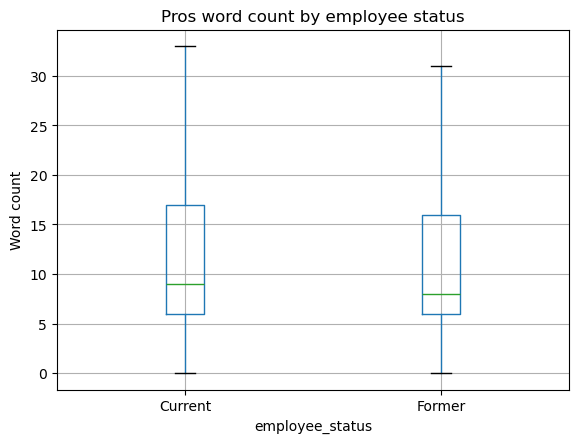

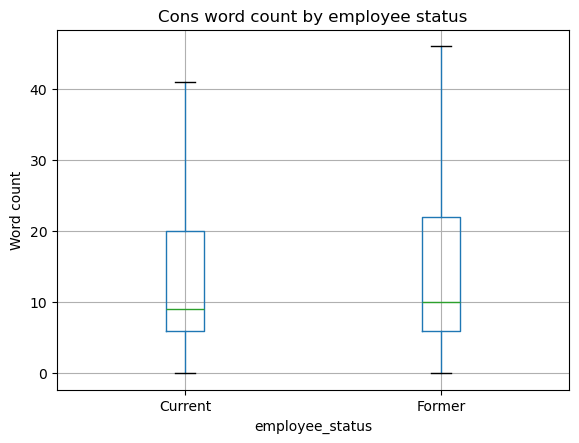

In [119]:
glassdoor_reviews.boxplot(column='pros_word_count', by='employee_status', showfliers = False)
plt.title('Pros word count by employee status')
plt.suptitle('')
plt.ylabel('Word count')
plt.show()

glassdoor_reviews.boxplot(column='cons_word_count', by='employee_status', showfliers = False)
plt.title('Cons word count by employee status')
plt.suptitle('')
plt.ylabel('Word count')
plt.show()

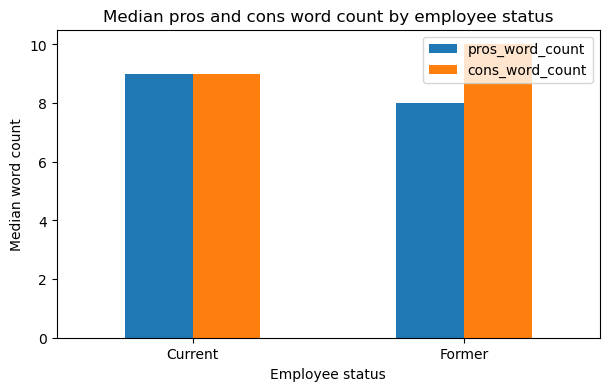

In [120]:
glassdoor_reviews.groupby('employee_status')[
    ['pros_word_count', 'cons_word_count']
].median().plot(kind='bar', figsize=(7, 4))

plt.xlabel('Employee status')
plt.ylabel('Median word count')
plt.title('Median pros and cons word count by employee status')
plt.xticks(rotation=0)
plt.show()

Comparing text length by employee status helps assess whether current and former employees differ not only in rating levels, but also in the way they express feedback. Differences in the average or median length of **pros** and **cons** may indicate different reviewing styles across employee groups.

In [121]:
glassdoor_reviews['rating_group'] = pd.cut(
    glassdoor_reviews['overall_rating'],
    bins=[0, 2, 3, 5],
    labels=['Low (1-2)', 'Medium (3)', 'High (4-5)']
)

glassdoor_reviews.groupby('rating_group', observed = True)[['pros_word_count', 'cons_word_count']].mean()

,pros_word_count,cons_word_count
rating_group,,
Low (1-2),14.836612,47.139415
Medium (3),13.908428,21.241842
High (4-5),15.334694,14.084604


Grouping reviews by overall rating allows a simple comparison between more positive and more negative evaluations. This can help show whether dissatisfied employees tend to write longer negative comments or whether highly satisfied employees provide shorter and more formulaic positive feedback.

Overall, the textual exploration shows that the dataset contains a useful combination of short summaries and longer written comments. The **headline** field is concise, while **pros** and **cons** provide richer written feedback. At the same time, many entries in both pros and cons are repetitive and formulaic, which suggests that more advanced text analysis methods may be useful in the next stage.

## Basic Text Mining of Pros and Cons / Token Analysis

### Pros

After the exploratory analysis of text length and frequent full expressions, the next step is to examine the vocabulary used in the **pros** and **cons** fields at token level. Basic text mining makes it possible to identify the most common words and phrases in positive and negative employee feedback and to move from full-text inspection to more systematic textual patterns.\
At this stage, the analysis uses standard stopword removal and *CountVectorizer()* in order to extract the most frequent terms from the cleaned text fields. The goal is descriptive rather than predictive: to identify the dominant themes in positive and negative workplace comments.

In [131]:
pros_text = glassdoor_reviews['pros_clean'].dropna()
pros_text = pros_text[pros_text.str.strip() != '']

In [132]:
pros_vectorizer = CountVectorizer(stop_words='english')
pros_bow = pros_vectorizer.fit_transform(pros_text)

In [135]:
pros_word_counts = pd.DataFrame({
    'word': pros_vectorizer.get_feature_names_out(),
    'count': np.asarray(pros_bow.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)
pros_word_counts.head(20)

,word,count
24497,good,333225
58509,work,310319
24974,great,247362
40245,people,151296
11997,company,106498
7018,benefits,105803
19324,environment,82390
58662,working,77128
38197,opportunities,74268
14287,culture,71590


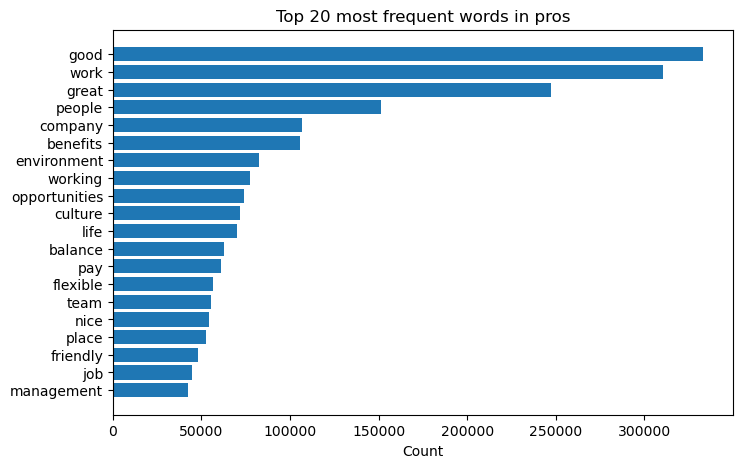

In [136]:
top_pros_words = pros_word_counts.head(20)

plt.figure(figsize=(8, 5))
plt.barh(top_pros_words['word'][::-1], top_pros_words['count'][::-1])
plt.xlabel("Count")
plt.title("Top 20 most frequent words in pros")
plt.show()

Token-level analysis of **pros** field shows that positive employee feedback is dominated strongly favorable vocabulary. The most frequent words suggests that positive reviews most often emphasize workplace quality, supportive colleagues, company culture, benefits and opportunities for growth. At the same time, the dominance of highly general evaluative words such as *good* and *great* indicates that much of the positive feedback is formulaic and concise.

In [138]:
pros_bigram_vectorizer = CountVectorizer(stop_words = 'english', ngram_range=(2,2))
pros_bigram_bow = pros_bigram_vectorizer.fit_transform(pros_text)

In [140]:
pros_bigrams = pd.DataFrame({
    'bigram': pros_bigram_vectorizer.get_feature_names_out(),
    'count': np.asarray(pros_bigram_bow.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)

pros_bigrams.head(20)

,bigram,count
1382224,work life,59714
729432,life balance,58219
544142,good work,30617
951797,place work,25656
554149,great people,22539
537795,good benefits,20744
551110,great benefits,20065
1380384,work environment,19226
541845,good pay,18933
934352,people work,17546


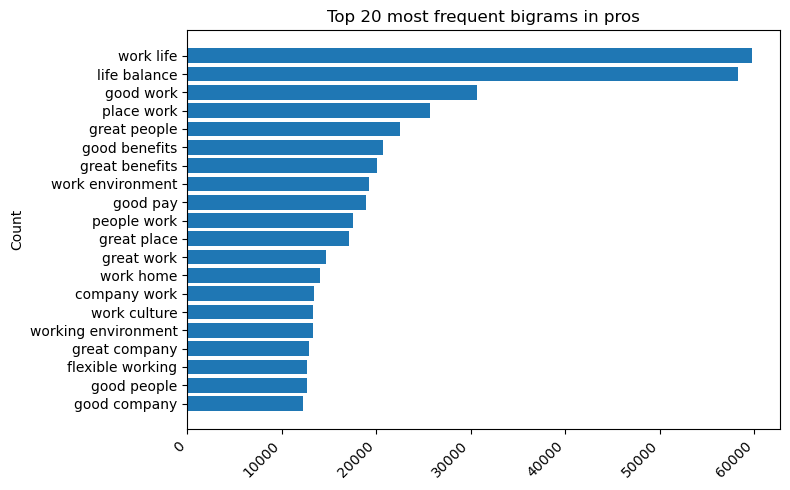

In [169]:
top_pros_bigrams = pros_bigrams.head(20)

plt.figure(figsize=(8, 5))
plt.barh(top_pros_bigrams['bigram'][::-1], top_pros_bigrams['count'][::-1])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Top 20 most frequent bigrams in pros')
plt.tight_layout()
plt.show()

Bigram analysis provides more context than single-word frequencies by highlighting reccuring short expressions rather than isolated tokens. In the standard version, most frequent bigrams show that positive employee feedback is especially centeres around work-life balance, workplace environment, compensation, flexibility and relationships with colleagues. The bigrams therefore confirm that favorable reviews are not only positive in tone, but also concentrated around a few clear themes.

In [157]:
custom_stopwords = list(text.ENGLISH_STOP_WORDS.union({'good', 'great'}))
pros_bigram_vectorizer_cw = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2, 2))

In [158]:
pros_bigram_bow_cw = pros_bigram_vectorizer_cw.fit_transform(pros_text)

In [159]:
pros_bigrams_cw = pd.DataFrame({
    'bigram': pros_bigram_vectorizer_cw.get_feature_names_out(),
    'count': np.asarray(pros_bigram_bow_cw.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)

pros_bigrams_cw.head(20)

,bigram,count
1401904,work life,59748
732586,life balance,58226
960782,place work,25742
1400035,work environment,19472
942959,people work,19224
1401164,work home,14074
248039,company work,14010
1399276,work culture,13715
1413061,working environment,13303
497122,flexible working,12710


In [160]:
custom_stopwords = list(text.ENGLISH_STOP_WORDS.union({'good', 'great', 'work'}))
pros_bigram_vectorizer_cw = CountVectorizer(stop_words=custom_stopwords, ngram_range=(2, 2))

In [161]:
pros_bigram_bow_cw = pros_bigram_vectorizer_cw.fit_transform(pros_text)

In [162]:
pros_bigrams_cw = pd.DataFrame({
    'bigram': pros_bigram_vectorizer_cw.get_feature_names_out(),
    'count': np.asarray(pros_bigram_bow_cw.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)

pros_bigrams_cw.head(20)

,bigram,count
744575,life balance,59038
1429049,working environment,13316
505465,flexible working,12715
504327,flexible hours,11758
1202398,smart people,10839
869257,nice people,8950
1429662,working hours,7847
521261,free food,6800
732422,learning opportunities,6460
482930,fast paced,6407


In order to reduce the dominance of highly repetative evaluative words such as **good** and **great**, an additional refined version of bigram analysis was performed. A further version excluding **work** was also used to reveal themes that might otherwise remain hidden behind very general workplace expressions. In this refined view, reccuring bigrams such as *life balance, working environment, flexible working, flexible hours, smart people, nice people, learning opportunities, pay bekefits, friendly environment, company culture, decent pay, friendly staff* become more visible, This suggests that, beyond general positive sentiment, employees most often value flexibility, balance, supportive colleagues, learning opportunities, compensation and workplace culture

Overall, the token analysis of **pros** confirms that positive employee feedback is highly repetitive but also clearly interpretable, with dominant themes related to balance, flexibility, people, culture and benefits.

### Cons

In [163]:
cons_text = glassdoor_reviews['cons_clean'].dropna()
cons_text = cons_text[cons_text.str.strip() != '']

In [164]:
cons_vectorizer = CountVectorizer(stop_words='english')
cons_bow = cons_vectorizer.fit_transform(cons_text)

In [165]:
cons_word_counts = pd.DataFrame({
    'word': cons_vectorizer.get_feature_names_out(),
    'count': np.asarray(cons_bow.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)
cons_word_counts.head(20)

,word,count
83149,work,210727
45703,management,120825
36684,hours,99936
16260,company,81797
55807,people,73763
44611,long,72785
55322,pay,72406
75683,time,65004
43814,life,58479
83296,working,58451


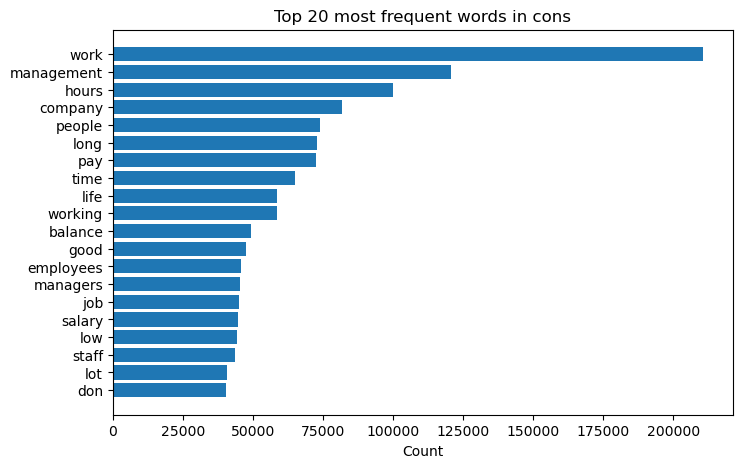

In [166]:
top_cons_words = cons_word_counts.head(20)

plt.figure(figsize=(8, 5))
plt.barh(top_cons_words['word'][::-1], top_cons_words['count'][::-1])
plt.xlabel("Count")
plt.title("Top 20 most frequent words in cons")
plt.show()

The token-level results for negative feedback reveal a much more problem-oriented vocabulary than the positive side. The most frequent words emphasize issues related to managemment, long working hours, low pay, time pressure and workload. This suggests that negative reviews are less centered on general evaluative language and more focused on concrete workplace problems.

In [167]:
cons_bigram_vectorizer = CountVectorizer(stop_words = 'english', ngram_range=(2,2))
cons_bigram_bow = cons_bigram_vectorizer.fit_transform(cons_text)

In [168]:
cons_bigrams = pd.DataFrame({
    'bigram': cons_bigram_vectorizer.get_feature_names_out(),
    'count': np.asarray(cons_bigram_bow.sum(axis=0)).ravel()
}).sort_values('count', ascending = False)

cons_bigrams.head(20)

,bigram,count
2538349,work life,46341
1283801,life balance,44828
1324890,long hours,35193
2552561,working hours,13249
1347329,low pay,10981
2056070,senior management,9134
1326529,long working,7782
1003012,hard work,6745
1723911,poor management,6417
1347753,low salary,6340


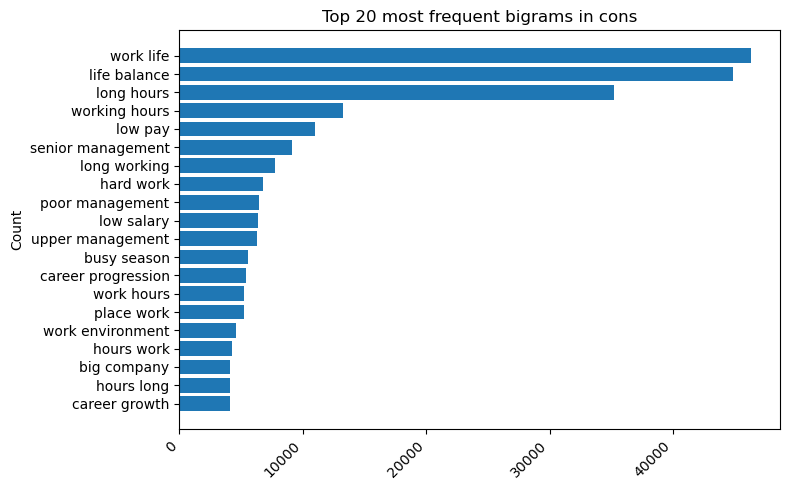

In [171]:
top_cons_bigrams = cons_bigrams.head(20)

plt.figure(figsize=(8, 5))
plt.barh(top_cons_bigrams['bigram'][::-1], top_cons_bigrams['count'][::-1])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Top 20 most frequent bigrams in cons')
plt.tight_layout()
plt.show()

The bigram analysis strengthens this interpretation by showing reccuring expressions such as *long hours, low pay, senior management, poor management, hard work, busy season, career prograssion and career growth*. At the same time, phrases related to balance also appear frequently, indicating that work-life balance is discussed not only as positive feature, but also as a common source of dissatisfaction.

Overall, the negative-feedback vocabulary appears more specific and problem-driven than the posivtive-feedback vocabulary. While positive comments are often short and formulaic, negative comments are more often point to identifiable source of dissatisfaction, especially management quality, compensation, workload and limited growth opportunities.

The Glassdoor analysis shows that workplace evaluations in the dataset are generally more positive than negative, but clear differences appear across employee groups, time, and feedback type. Current employees consistently rate their workplace more favorably than former employees, while text analysis suggests that positive feedback is often broad and repetitive, whereas negative feedback more frequently points to specific workplace problems such as management, workload, compensation, and career progression.

## Macroeconomic context from the World Bank Dataset

### Reshaping and preparation of the World Bank dataset

In order to place the employee-review feedback in a broader contex, the analysis is supplemented with selected macroeconomic indicators from the World Bank. Unlike the Glassdoor dataset, which provides individual-level workplace evaluations, the World Bank data is used only as a contextual source. Its role is to describe broader economic conditions over time, particularly in relation to inflation, unemployment and general economic performance.\
Since the World Bank file is stored in wide format, with years as separate columns, the first step is to reshape it into a long format that is more suitable for filtering

In [175]:
world_bank = pd.read_csv('world_bank_data.csv')
world_bank.head()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Argentina,ARG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,10.1253981561002,6.00395169280579,-1.0264204544321,2.40532378079436,-2.51261532081394,2.73115982828944,-2.08032784377811,2.81850297775918,-2.617396,-2.000861,-9.900485,10.441812,6.020745,-1.855788,-1.342931,..
1,Argentina,ARG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,..,..,..,..,..,..,..,..,34.277224,53.548304,42.015095,48.409379,72.430758,133.488936,219.883929,..
2,Argentina,ARG,"Unemployment, male (% of male labor force) (mo...",SL.UEM.TOTL.MA.ZS,6.685,6.267,6.101,6.137,6.494,6.796,7.291,7.544,8.246000,9.202000,10.778000,7.915000,6.145000,5.641000,6.576000,6.397
3,Argentina,ARG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,7.714,7.18,7.217,7.1,7.268,7.577,8.088,8.347,9.220000,9.843000,11.461000,8.736000,6.805000,6.139000,7.150000,7.145
4,Argentina,ARG,"Unemployment, female (% of female labor force)...",SL.UEM.TOTL.FE.ZS,9.221,8.522,8.841,8.508,8.394,8.704,9.227,9.485,10.563000,10.718000,12.394000,9.852000,7.682000,6.793000,7.912000,8.136


In [176]:
world_bank.shape

(105, 20)

In [177]:
world_bank.columns.to_list()

['Country Name',
 'Country Code',
 'Series Name',
 'Series Code',
 '2010 [YR2010]',
 '2011 [YR2011]',
 '2012 [YR2012]',
 '2013 [YR2013]',
 '2014 [YR2014]',
 '2015 [YR2015]',
 '2016 [YR2016]',
 '2017 [YR2017]',
 '2018 [YR2018]',
 '2019 [YR2019]',
 '2020 [YR2020]',
 '2021 [YR2021]',
 '2022 [YR2022]',
 '2023 [YR2023]',
 '2024 [YR2024]',
 '2025 [YR2025]']

In [178]:
world_bank.head(3)

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Argentina,ARG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,10.1253981561002,6.00395169280579,-1.0264204544321,2.40532378079436,-2.51261532081394,2.73115982828944,-2.08032784377811,2.81850297775918,-2.617396,-2.000861,-9.900485,10.441812,6.020745,-1.855788,-1.342931,..
1,Argentina,ARG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,..,..,..,..,..,..,..,..,34.277224,53.548304,42.015095,48.409379,72.430758,133.488936,219.883929,..
2,Argentina,ARG,"Unemployment, male (% of male labor force) (mo...",SL.UEM.TOTL.MA.ZS,6.685,6.267,6.101,6.137,6.494,6.796,7.291,7.544,8.246000,9.202000,10.778000,7.915000,6.145000,5.641000,6.576000,6.397


In [179]:
years_columns = [col for col in world_bank.columns if '[YR' in col]

In [186]:
world_bank_long = world_bank.melt(
    id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars = years_columns,
    var_name = 'year',
    value_name = 'value'
)

world_bank_long.head()

,Country Name,Country Code,Series Name,Series Code,year,value
0,Argentina,ARG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2010 [YR2010],10.1253981561002
1,Argentina,ARG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010 [YR2010],..
2,Argentina,ARG,"Unemployment, male (% of male labor force) (mo...",SL.UEM.TOTL.MA.ZS,2010 [YR2010],6.685
3,Argentina,ARG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2010 [YR2010],7.714
4,Argentina,ARG,"Unemployment, female (% of female labor force)...",SL.UEM.TOTL.FE.ZS,2010 [YR2010],9.221


In [190]:
world_bank_long['year'] = world_bank_long['year'].astype(str).str.extract(r'(\d{4})').astype(int)
world_bank_long['value'] = pd.to_numeric(world_bank_long['value'], errors = 'coerce')
world_bank_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  1632 non-null   object 
 1   Country Code  1600 non-null   object 
 2   Series Name   1600 non-null   object 
 3   Series Code   1600 non-null   object 
 4   year          1680 non-null   int64  
 5   value         1552 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 78.9+ KB


In [208]:
world_bank_long = world_bank_long.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    'Series Name': 'series_name',
    'Series Code': 'series_code'
})
world_bank_long.head()


,country,country_code,series_name,series_code,year,value
0,Argentina,ARG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2010,10.125398
1,Argentina,ARG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,NaN
2,Argentina,ARG,"Unemployment, male (% of male labor force) (mo...",SL.UEM.TOTL.MA.ZS,2010,6.685000
3,Argentina,ARG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2010,7.714000
4,Argentina,ARG,"Unemployment, female (% of female labor force)...",SL.UEM.TOTL.FE.ZS,2010,9.221000


The World Bank data was originally stored in wide format, with each year represented as a separate column. To make the dataset suitable for filtering and visualisation, it was reshaped into long format, producing one row per country, indicator and year. The year values were then extracted into numberic form and the indicator values were converted to numeric type. This transformation made it possible to analyze temporal trends in inflation, unemployment and GDP growth in a consistent way.

### Inflation over time

In [209]:
world_bank_long['series_name'].unique()

array(['GDP growth (annual %)', 'Inflation, consumer prices (annual %)',
       'Unemployment, male (% of male labor force) (modeled ILO estimate)',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)',
       'Unemployment, female (% of female labor force) (modeled ILO estimate)',
       nan], dtype=object)

In [210]:
world_bank_long['country'].unique()

array(['Argentina', 'Australia', 'Brazil', 'China', 'France', 'Germany',
       'India', 'Indonesia', 'Italy', 'Japan', 'Korea, Rep.', 'Mexico',
       'Netherlands', 'Russian Federation', 'Saudi Arabia', 'Spain',
       'Switzerland', 'Turkiye', 'United Kingdom', 'United States', nan,
       'Data from database: World Development Indicators',
       'Last Updated: 04/08/2026'], dtype=object)

In [254]:
selected_countries = ['Argentina', 'Brazil', 'China', 'Germany','Russian Federation', 'Turkiye', 'United States']
wb_selected = world_bank_long[world_bank_long['country'].isin(selected_countries)].copy()

In [255]:
inflation = wb_selected[wb_selected['series_name'] == 'Inflation, consumer prices (annual %)']

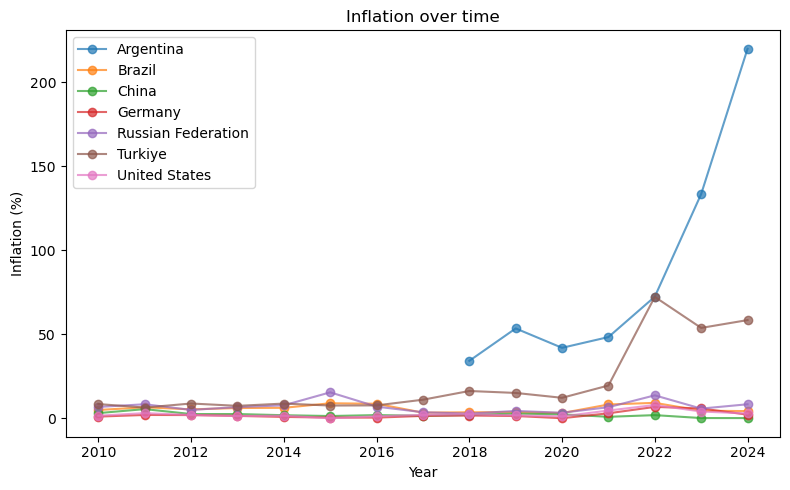

In [256]:
plt.figure(figsize = (8, 5))
for country in inflation['country'].unique():
    subset = inflation[inflation['country'] == country]
    plt.plot(subset['year'], subset['value'], alpha = 0.7, marker = 'o', label = country)

plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.title('Inflation over time')
plt.legend()
plt.tight_layout()
plt.show()

The inflation data shows clear difference across countries and across years. For most countries, inflation remains relatively moderate during much of the period, but a visible increase appears around 2021-2023. Some countries experience substantially stronger price growth than others, ondicating that inflationary pressure was not evenly distributed. This is relevant to the employee-review analysis because compensation and pay-related concernss appeared repeatedly in the negative feedback and inflation provides useful macroeconomic context for why such concerns may become more salient.

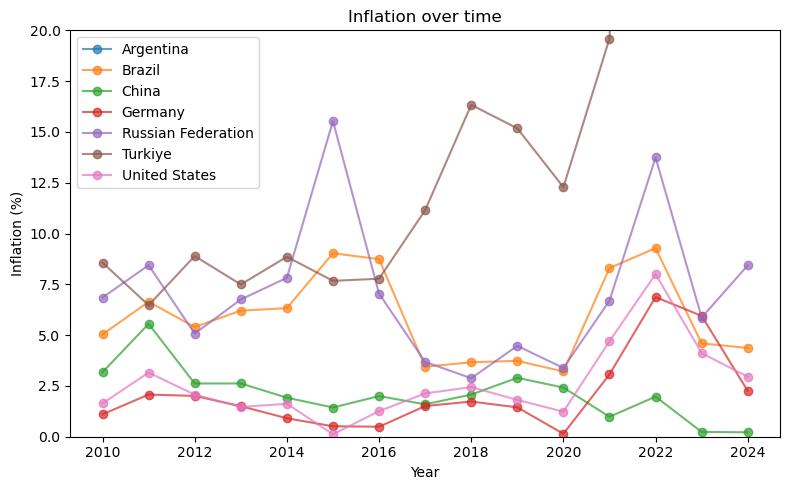

In [257]:
plt.figure(figsize = (8, 5))
for country in inflation['country'].unique():
    subset = inflation[inflation['country'] == country]
    plt.plot(subset['year'], subset['value'], alpha = 0.7, marker = 'o', label = country)
plt.ylim(0, 20)
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.title('Inflation over time')
plt.legend()
plt.tight_layout()
plt.show()

When the scale is restricted to a narrower range, the inflation patterns of most countries become easier to compare. The chart shows that, despite important cross-country differences, many countries experienced a noticeable rise in inflation in the later years of the period. This suggests a shared period of icreased cost-of-living pressure, even if intensity varied substantially across countries.

### Total unemployment over time 

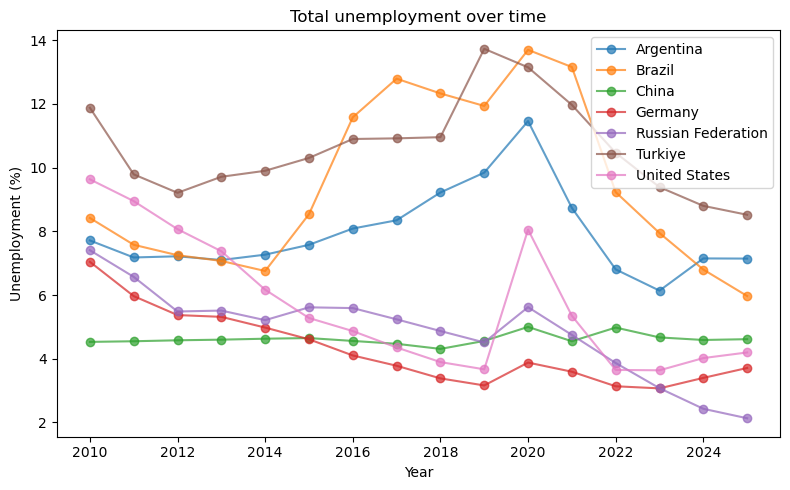

In [258]:
unemployment_total = wb_selected[
    wb_selected['series_name'] == 'Unemployment, total (% of total labor force) (modeled ILO estimate)'
]

plt.figure(figsize=(8, 5))
for country in unemployment_total['country'].unique():
    subset = unemployment_total[unemployment_total['country'] == country]
    plt.plot(subset['year'], subset['value'], alpha = 0.7, marker='o', label=country)

plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.title('Total unemployment over time')
plt.legend()
plt.tight_layout()
plt.show()

Total unemployment also varies considerably across countries, Some countries show relatively stable and lower unemployment rates, while others experience persistently higher levels or stronger fluctuations over time. A notable disturbance is visible around 2020-2021 in several countries, followed by impovement in later years. This indicator is useful as a broad measure of labor-market conditions and provides background for interpreting review themes related to workload, job security and career opportunities.

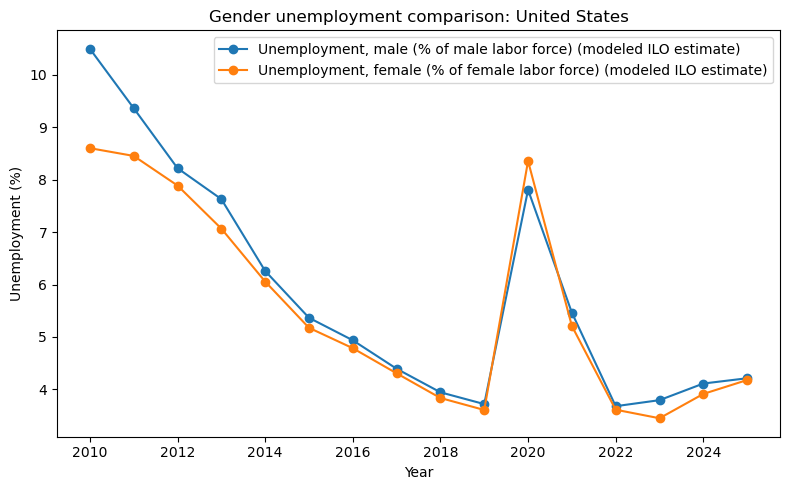

In [259]:
country_name = 'United States'

unemp_gender = wb_selected[
    (wb_selected['country'] == country_name) &
    (wb_selected['series_name'].isin([
        'Unemployment, male (% of male labor force) (modeled ILO estimate)',
        'Unemployment, female (% of female labor force) (modeled ILO estimate)'
    ]))
]

plt.figure(figsize=(8, 5))
for series in unemp_gender['series_name'].unique():
    subset = unemp_gender[unemp_gender['series_name'] == series]
    plt.plot(subset['year'], subset['value'], marker='o', label=series)

plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.title(f'Gender unemployment comparison: {country_name}')
plt.legend()
plt.tight_layout()
plt.show()

The comparison between male and female unemployment in the United States shows that both series follow a very similar time pattern. Unemployment declines over the earlier years, rises sharply around 2020 and then falls again before stabilizing. The gap between male and female unemployment is generally small, which suggests that the main dynamic is driven more by overall labor-market shocks than by large geder difference in this specific case.

### GDP growth overtime

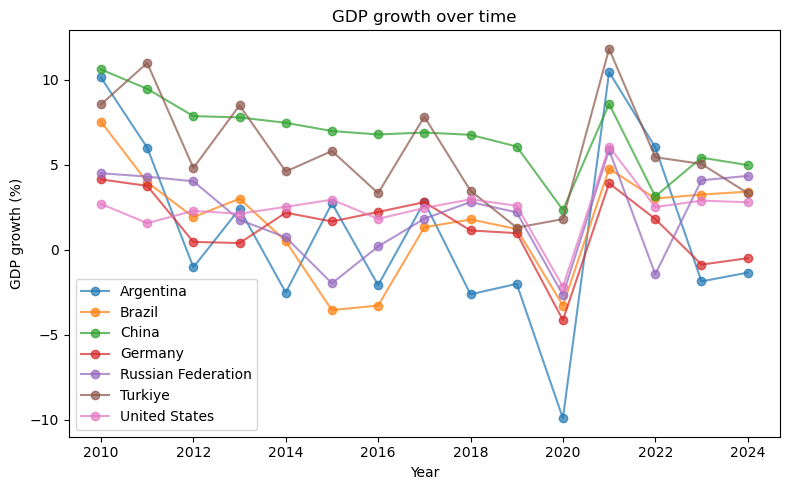

In [261]:
gdp_growth = wb_selected[
    wb_selected['series_name'] == 'GDP growth (annual %)'
]

plt.figure(figsize=(8, 5))
for country in gdp_growth['country'].unique():
    subset = gdp_growth[gdp_growth['country'] == country]
    plt.plot(subset['year'], subset['value'], alpha = 0.7, marker='o', label=country)

plt.xlabel('Year')
plt.ylabel('GDP growth (%)')
plt.title('GDP growth over time')
plt.legend()
plt.tight_layout()
plt.show()

GDP growth displays the strongest volatility among the selected macroeconomic indicators. Most countries show a sharp contraction sround 2020, followed by a rebound in 2021 and more moderate growth afterward. This pattern reflects a major macroeconomic shock followed by recovery. Although GDP growth does not explain individual employee reviews directly, it helps describe the broader economic environment in which workplace perceptions were formed.

Overall, the Wrold Bank indicators provide useful macroeconomic context for the employee-review analysis. Inflation highlights changes in cost-of-living pressure, unemployment reflects labor-market conditions and GDP growth captures broader economic shocks and recovery. These variables are not used to explain individual reviews directly, but they help situate employee concerns about pay, workload and careee prospects within wider economic background

## Integrating Employee Reviews with Macroeconomic Context

The two data sources used in this project operate at different levels of analysis and therefore serve different purposes. The Glassdoor dataset captures individual workplace perceptions expressed through ratings and written comments, while the World Bank dataset describes broader macroeconomic conditions over time. For this reason, the relationship between the two sources should be interpreted as contextual rather than causal. The macroeconomic indicators do not explain individual reviews directly, but they provide a useful background for understanding why certain themes may become more salient in employee feedback during specific periods.\
The Glassdoor analysis shows that employee evaluations in the dataset are, on average, more positive than negative, with ratings of 4 and 5 occurring more frequently than low ratings. At the same time, the analysis also reveals substantial variation across employee groups and across review content. Former employees consistently rate their workplace less favorably than current employees and the strongest structured associations with overall rating are found for culture values, senior management and career opportunities. The text analysis complements this picture by showing that positive feedback is often broad and formulaic, centered on work-life balance, supportive people, flexibility, benefits and workplace culture, whereas negative feedback is more concrete and problem-oriented, focusing on long hours, management quality, low pay, workload pressure and limited progression.\
The World Bank indicators help place these findings in a wider economic setting. Inflation, unemployment and GDP growth all show visible changes across the observed period, with a particularly strong macroeconomic disruption around 2020–2021 and, in several cases, continued instability in the years that followed. The sharp break in GDP growth and the labor-market disturbance around 2020 are consistent with the global shock associated with the COVID-19 pandemic, while later inflationary pressures can also be interpreted in the context of post-pandemic recovery dynamics and, especially for some countries, the broader economic consequences of the Russia–Ukraine war. These shifts do not determine how individual employees write about their workplace, but they help explain why issues related to compensation, workload, job security and career prospects remain central in employee discourse.\
This contextual connection is especially visible in the contrast between the structured and textual Glassdoor results. On the one hand, the ratings suggest that many employees evaluate their workplace positively overall, particularly current employees. On the other hand, the negative text reveals recurring dissatisfaction with pay, management, and working time. In this sense, the employee reviews do not simply reflect abstract satisfaction or dissatisfaction; they also capture concrete workplace tensions that are likely to become more important during periods of economic stress. When inflation rises, for example, compensation may be experienced as less adequate even if the nominal workplace environment remains stable. Similarly, when growth weakens or unemployment becomes more uncertain, concerns related to management, progression and workload may become more pronounced in employee evaluations.\
The temporal patterns in the Glassdoor data are also informative when viewed alongside the macroeconomic series. Review volume increases strongly in later years, especially after 2014 and again around 2020–2021, while average overall ratings show a gradual upward tendency over time. This means that the review environment itself is changing: later years are represented by more observations and somewhat more favorable average ratings. The macroeconomic context helps qualify the interpretation of these trends. It suggests that later employee reviews were produced in a period marked by major external shocks, changing labor-market conditions and heightened price pressure. Therefore, even when average ratings remain relatively positive, the persistence of compensation- and workload-related criticism in the text becomes particularly meaningful.\
Taken together, the two datasets provide a more complete analytical picture than either source could offer alone. The employee-review data shows how workers describe and evaluate their workplace experience, while the macroeconomic indicators show the broader environment in which these perceptions are formed. The combined reading of both sources suggests that workplace evaluations are shaped not only by internal organizational factors such as management quality, culture and career opportunities, but also by external economic conditions that influence how employees experience pay, pressure and job stability. Although this project does not claim a direct causal link between macroeconomic change and employee review content, the contextual alignment between recurring workplace concerns and broader economic instability makes the integrated interpretation both reasonable and analytically valuable.

## Main Findings

The most important result of the project is that workplace evaluation in the dataset is not driven by a single dimension, but by the interaction of organizational climate, managerial quality, career prospects and everyday working conditions. Although the overall rating distribution is tilted toward the positive end of the scale, this aggregate pattern conceals meaningful internal contrasts. In particular, current and former employees do not simply differ in degree, but appear to occupy systematically different evaluative positions, with former employees expressing a more critical reading of the workplace across all major structured dimensions.\
A second key finding is that the strongest drivers of overall evaluation are not the most immediate or purely material aspects of employment. While compensation and work-life balance clearly matter, the analysis suggests that broader institutional factors - especially culture values, senior management and career opportunities - are more tightly connected to general workplace judgment. This implies that employee satisfaction in the dataset is shaped not only by what work offers in the present, but also by how the organization is experienced as a social system and as a space for future development.\
The text analysis sharpens this distinction further. Positive feedback tends to be linguistically compressed, repetitive and formulaic, relying on broad expressions of approval around balance, flexibility, benefits and collegial environment. Negative feedback, by contrast, is more specific and diagnostically useful: it is less about general dissatisfaction and more about identifiable points of friction, especially management quality, long hours, low pay, workload pressure and blocked progression. In that sense, the negative reviews carry greater explanatory density, because they describe workplace dissatisfaction in more concrete and operational terms.\
Taken together, the structured and textual evidence point to a consistent interpretation: favorable workplace evaluations are often expressed as a general sense of organizational comfort, whereas unfavorable evaluations are more likely to emerge when employees perceive failures in management, recognition, workload distribution or long-term opportunity. The macroeconomic context strengthens this reading without determining it. The external shocks visible around 2020–2021 and the inflationary pressures that follow, do not explain individual reviews directly, but they make the recurring concerns about pay, pressure and stability more intelligible within a broader economic environment.

### Hypotheses Evaluation

**H1.** *Higher ratings for work-life balance, compensation and benefits, career opportunities and senior management are associated with higher overall employee ratings.*\
**Supported.** The structured analysis shows that all core rating dimensions are positively related to overall evaluation. However, the associations are not equally strong: culture values, senior management and career opportunities emerge as the most influential dimensions, while work-life balance and compensation remain important but somewhat less central.

**H2.** *Former employees tend to leave less favorable reviews than current employees.*\
**Supported.** This pattern appears consistently across the dataset. Former employees report lower average values on all major structured rating variables and their overall rating distribution is visibly shifted downward relative to current employees. The difference is therefore not incidental, but systematic.

**H3.** *Negative textual reviews more frequently emphasize themes related to poor management, heavy workload, limited career growth and dissatisfaction with compensation.*\
**Supported.** The token and bigram analysis of negative feedback repeatedly highlights expressions related to management problems, long hours, low pay, workload pressure and restricted progression. This indicates that dissatisfaction is often articulated through specific and recurring workplace tensions rather than vague negative sentiment.

**H4.** *Positive textual reviews more frequently emphasize flexibility, supportive colleagues, benefits and workplace culture.*\
**Supported.** Positive feedback is dominated by themes related to work-life balance, flexibility, benefits, collegial environment and workplace culture. Although the language is often brief and formulaic, the recurring positive themes are clear and consistent.

**H5.** *Broader economic pressure may be reflected in stronger dissatisfaction with compensation-related aspects of work, although this relationship should be interpreted as contextual rather than causal.*\
**Partially supported.** The macroeconomic indicators show visible instability around 2020–2021 and rising inflationary pressure in later years, while the review data repeatedly points to compensation, workload and career concerns. This makes the contextual connection plausible and analytically useful. At the same time, the project does not establish a direct causal relationship between macroeconomic indicators and individual employee reviews, so the hypothesis is better treated as partially rather than fully confirmed.

### Limitations

Several limitations should be taken into account when interpreting the results of this project. First, the employee-review dataset is based on self-selected online submissions rather than on a representative sample of workers. Individuals who choose to leave reviews may differ systematically from those who do not, which means that the observed patterns reflect expressed review behavior rather than the full distribution of employee experience. In particular, online reviews may overrepresent employees with especially strong positive or negative opinions.\
A second limitation concerns the structure and consistency of the data itself. Although the main dataset is rich and highly informative, some variables contain substantial missingness, inconsistent formatting or uneven availability over time. This is especially relevant for fields such as diversity_inclusion, whose missingness appears to be structural rather than random and location, whose high cardinality and inconsistent formatting limited its direct analytical use. As a result, not all available variables could be incorporated into the core analysis to the same degree.\
The text-based results should also be interpreted with caution. Basic text mining is useful for identifying recurring vocabulary and short thematic patterns, but it does not fully capture nuance, irony, ambiguity or context-dependent meaning. Frequent-word and bigram analysis highlights dominant expressions, yet it cannot distinguish between subtle differences in tone or intention as precisely as more advanced language models or manual qualitative coding would. The text analysis in this project is therefore descriptive rather than exhaustive.\
Another important limitation is that the observed relationships are primarily associational. Strong correlations between overall evaluation and dimensions such as culture values, senior management or career opportunities indicate close empirical relationships, but they do not establish causal direction. Similarly, the finding that former employees evaluate their workplace more negatively should not be interpreted as evidence that leaving employment itself causes dissatisfaction or vice versa. The project identifies patterns of co-occurrence and difference, not causal mechanisms.\
The integration of the Glassdoor and World Bank datasets also requires careful interpretation. The two sources operate at fundamentally different levels: one captures individual workplace reviews, while the other describes country-level macroeconomic conditions. For this reason, the macroeconomic indicators provide context rather than direct explanatory power. They help situate recurring concerns about compensation, workload and job conditions within a broader economic environment, but they cannot be used to infer that changes in inflation, unemployment or GDP growth directly caused the review patterns observed in the employee dataset.\
Finally, the temporal dimension of the analysis has limits of its own. Later years in the review dataset contain a much larger number of observations than earlier years, which means that the dataset becomes denser over time. This improves visibility into more recent patterns, but it also makes long-run comparisons less symmetrical. In addition, the period under study includes major external shocks, most notably the COVID-19 pandemic and the macroeconomic instability that followed. These events form an important contextual backdrop, yet their effects on review behavior cannot be isolated precisely within the present design.\
Taken together, these limitations do not invalidate the findings, but they define their scope. The project offers a structured and informative analysis of employee reviews in relation to broader economic conditions, but its conclusions should be understood as analytically grounded, context-sensitive patterns rather than as universal or causal claims.

## Conclusion

This project shows that large-scale employee reviews can be turned into meaningful workplace insight when they are treated with methodological care. What initially appears as noisy and uneven raw data becomes analytically valuable once issues of duplication, missingness, inconsistent encoding and text variability are handled systematically.\
The final picture that emerges is a layered one: workplace evaluation is not reducible to a single score or a single workplace attribute. Instead, it reflects the combined effect of organizational culture, leadership, opportunity structures and everyday work conditions, while written feedback reveals where general satisfaction gives way to concrete friction. In that sense, the strongest value of the analysis lies not only in identifying whether employees evaluate their workplace positively or negatively, but in clarifying how that evaluation is formed.\
By combining review-level evidence with macroeconomic context, the project also shows that employee perception can be read more convincingly when it is placed within a wider economic environment. Even without claiming direct causality, this broader framing strengthens the interpretation of recurring concerns related to pay, pressure and stability.\
Overall, the project demonstrates both substantive insight and analytical process: it is not only an analysis of workplace reviews, but also an example of how imperfect real-world data can be transformed into a coherent and defensible data-science investigation.